# INSTALAR E IMPORTAR LIBRERÍAS NECESARIAS

In [1]:
!pip install mysql-connector-python

!pip install feature-engine

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.9/33.9 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 230.0/230.0 kB 3.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
pd.options.display.float_format = '{:.4f}'.format
pd.options.display.max_columns = None
import numpy as np
import mysql.connector
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import seaborn as sns
from scipy.stats import zscore
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.api import QuantReg
from statsmodels.stats.outliers_influence import variance_inflation_factor
from feature_engine.outliers import Winsorizer

# INGESTA DATOS

In [3]:
def obtener_datos():
    connection = mysql.connector.connect(
        user = "avnadmin",
        password = "AVNS_vBt5bLw5TLinvY6G_Eo",
        host = "estrie01-estimacionderiego1.j.aivencloud.com",
        database = "defaultdb",
        port = 24195
    )
    cursor = connection.cursor()
    sql = """
    SELECT  src.Date,
        src.Ticker,
        src.Open,
        src.Close,
        src.High,
        src.Low,
        src.Volume,
        (src.Open - src.Close) AS retorno,
        (src.Open - src.Close) / src.Open AS retorno_porcentaje,
        ABS(src.High - src.Low) AS amplitud,
        ABS(src.High - src.Low) / src.Open AS amplitud_porcentaje,
        CPI,
        Unemployment,
        Industrial_production,
        Fed_funds_rate,
        10_year_treasury,
        PCE,
        DFF,
        Target10,
        Target5,
        Target30
    FROM curated as src
    """

    cursor.execute(sql)
    result = cursor.fetchall()
    result = pd.DataFrame(result, columns=[i[0] for i in cursor.description])
    return result

In [4]:
df = obtener_datos()

In [5]:
df.dtypes

,0
Date,object
Ticker,object
Open,float64
Close,float64
High,float64
Low,float64
Volume,int64
retorno,float64
retorno_porcentaje,float64
amplitud,float64


In [6]:
df.set_index("Date",inplace=True)
df["Volume"] = df["Volume"].astype(int)
df = df.drop(columns="Ticker")
df.head()

,Open,Close,High,Low,Volume,retorno,retorno_porcentaje,amplitud,amplitud_porcentaje,CPI,Unemployment,Industrial_production,Fed_funds_rate,10_year_treasury,PCE,DFF,Target10,Target5,Target30
Date,,,,,,,,,,,,,,,,,,,
1927-12-30,17.6600,17.6600,17.6600,17.6600,0,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0091,-0.0210,-0.0226
1928-01-03,17.7600,17.7600,17.7600,17.7600,0,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0220,-0.0265,-0.0282
1928-01-04,17.7200,17.7200,17.7200,17.7200,0,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0209,-0.0260,-0.0260
1928-01-05,17.5500,17.5500,17.5500,17.5500,0,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0114,-0.0165,-0.0291
1928-01-06,17.6600,17.6600,17.6600,17.6600,0,0.0000,0.0000,0.0000,0.0000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.0176,-0.0226,-0.0402


<Axes: xlabel='Target30', ylabel='Count'>

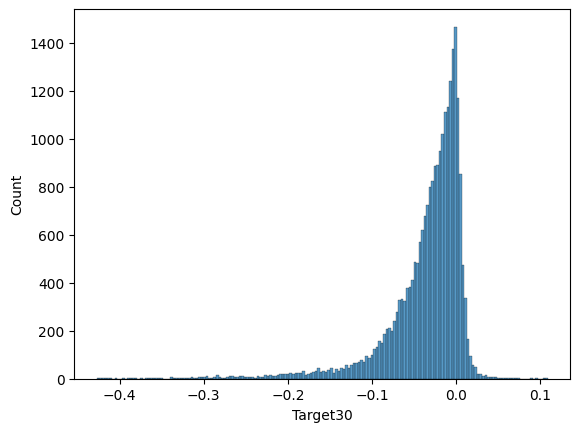

In [7]:
sns.histplot(df['Target30'])

# train test split

In [8]:
startidx = 0
for i,v in enumerate(df.index):
  if v.year==1995:
    startidx = i
    break

df1995 = df.iloc[startidx:,:]

In [9]:
train = df1995.iloc[:int(len(df1995)*0.8),:]
test = df1995.iloc[int(len(df1995)*0.8):,:]

# FILL

In [10]:
def back_lineal_foward(df1):
  na_columns = df1.columns[df1.isna().any()]

  # backfill para los primeros valores (busca el primer valor, vuelve y hace el backfill)
  for col in na_columns:
      first_valid_index = df1[col].first_valid_index()
      df1.loc[:first_valid_index] = df1.loc[:first_valid_index].bfill()

  # lo mismo para fowardfill (busca el último valor y aplica el fowardfill)
  for col in na_columns:
      last_valid_index = df1[col].last_valid_index()
      df1.loc[last_valid_index:] = df1.loc[last_valid_index:].ffill()

  # interpolación lineal para los valores del medio
  df1.interpolate(method='linear', inplace=True)
  return df1

# Variables

## **1. Variables de Volatilidad**

**Objetivo:** Capturan la magnitud, persistencia y dinámica de la variabilidad en retornos.

* `Var_rel_25`, `Var_rel_50`, `Var_rel_200`
* `Vol_10_adj`
* `Abs_Var_5d`
* `RollingShock_10`
* `EWMA_Volatility`
* `RealVol_5d`, `RealVol_20d`
* `ATR`

Estas variables reflejan condiciones de mercado agitadas o tranquilas, lo cual es fundamental ya que la alta volatilidad suele preceder drawdowns significativos.



In [11]:
train_var = train.copy()
test_var = test.copy()

def relative_volatility(df, windows):
  df = df.copy()
  for w in windows:
    vol = df["retorno_porcentaje"].rolling(window=w).std()
    pmc = vol.rolling(window=w).mean()
    df[f"Var_rel_{w}"] = (vol - pmc)/pmc
  return df

train_var = relative_volatility(train_var, [25, 50, 200])
test_var = relative_volatility(test_var, [25, 50, 200])

def volatility_adj(df):
  df=df.copy()
  vol_10 = df['retorno_porcentaje'].rolling(window=10).std()
  vol_50 = df['retorno_porcentaje'].rolling(window=50).std()
  df['Vol_10_adj'] = vol_10 / vol_50
  return df

train_var = volatility_adj(train_var)
test_var = volatility_adj(test_var)

def abs_volatility(df):
  df = df.copy()
  df['Abs_Var_5d'] = df['retorno_porcentaje'].rolling(window=5).apply(lambda x: np.abs(x[-1] - x[0]), raw=True)
  return df

train_var = abs_volatility(train_var)
test_var = abs_volatility(test_var)

def rolling_shock(df):
    df = df.copy()
    df['RollingShock_10'] = (df['retorno_porcentaje'] - df['retorno_porcentaje'].rolling(window=2).mean())**2
    df['RollingShock_10'] = df['RollingShock_10'].rolling(window=10).mean()
    return df

train_var = rolling_shock(train_var)
test_var = rolling_shock(test_var)

def calc_EWMA_Volatility(df, span=20):
    df = df.copy()
    df['EWMA_Volatility'] = df['retorno'].ewm(span=span, adjust=False).std()
    return df

train_var = calc_EWMA_Volatility(train_var)
test_var = calc_EWMA_Volatility(test_var)

def calc_realized_volatility(df):
    df = df.copy()
    df["RealVol_5d"] = df["retorno_porcentaje"].rolling(window=5).std()
    df["RealVol_20d"] = df["retorno_porcentaje"].rolling(window=20).std()
    return df

train_var = calc_realized_volatility(train_var)
test_var = calc_realized_volatility(test_var)

def calc_ATR(df, window=14):
    df = df.copy()
    df['H-L'] = df['High'] - df['Low']
    df['H-PC'] = np.abs(df['High'] - df['Close'].shift(1))
    df['L-PC'] = np.abs(df['Low'] - df['Close'].shift(1))
    df['TR'] = df[['H-L', 'H-PC', 'L-PC']].max(axis=1)
    df['ATR'] = df['TR'].rolling(window=window).mean()
    df.drop(['H-L', 'H-PC', 'L-PC', 'TR'], axis=1, inplace=True)
    return df

train_var = calc_ATR(train_var)
test_var = calc_ATR(test_var)

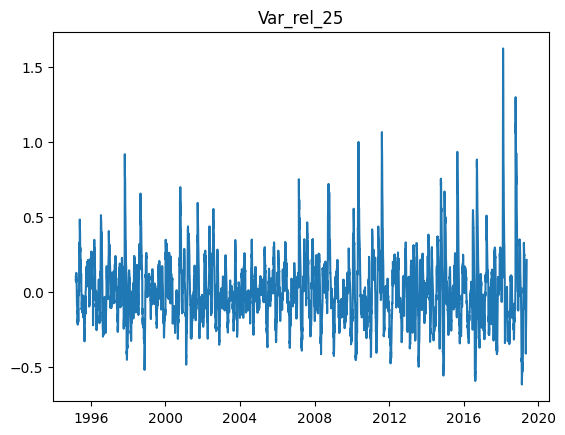

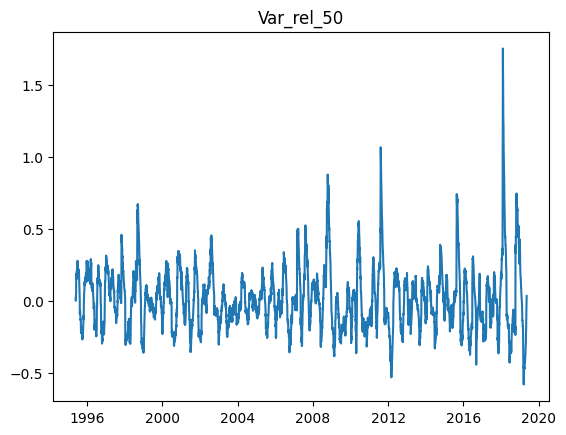

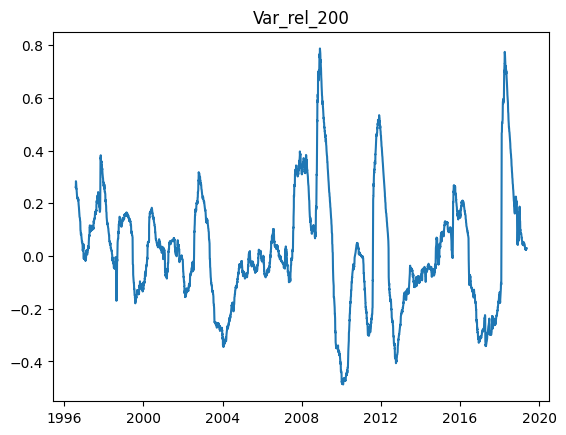

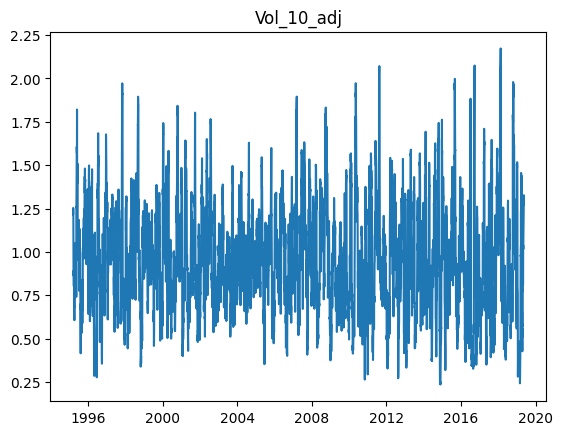

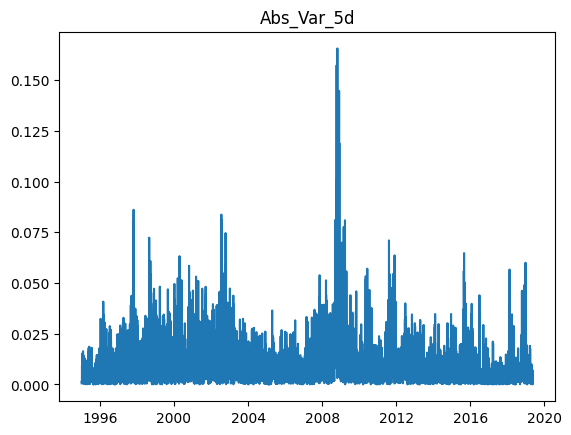

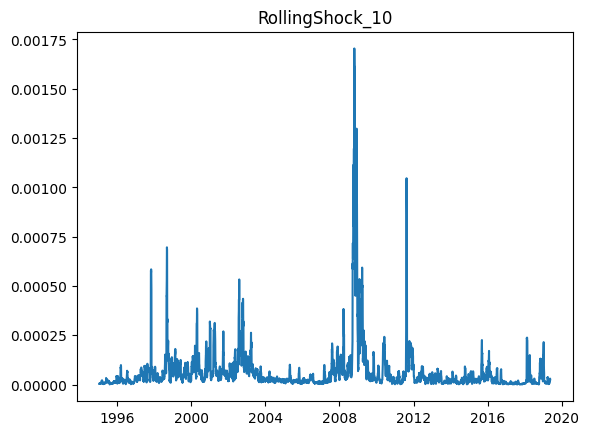

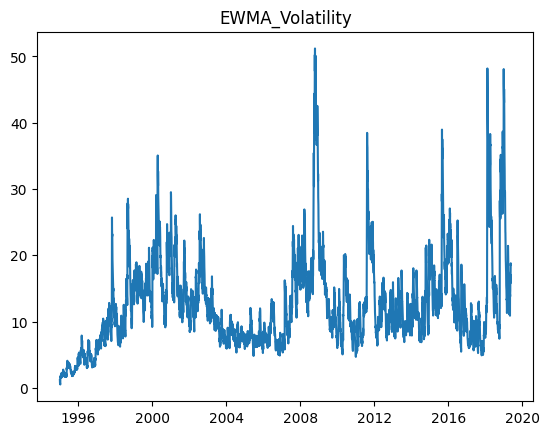

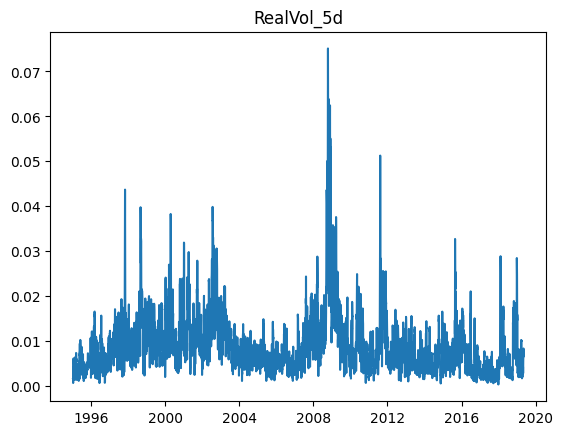

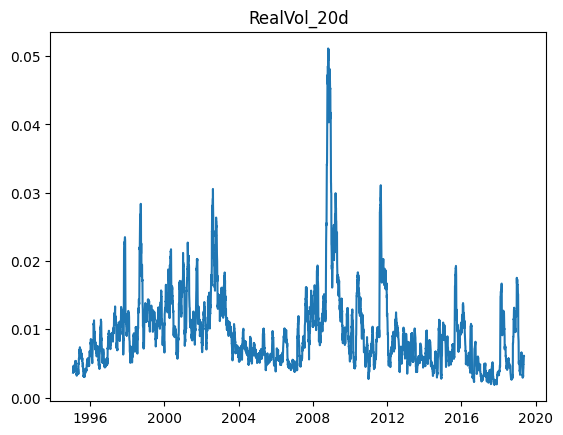

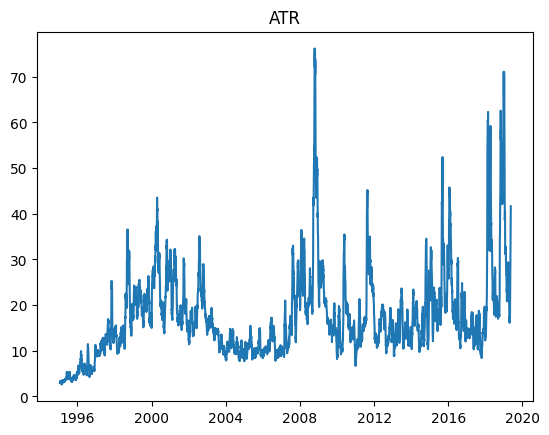

In [12]:
var_features = ['Var_rel_25', 'Var_rel_50', 'Var_rel_200', 'Vol_10_adj', 'Abs_Var_5d', 'RollingShock_10', 'EWMA_Volatility', 'RealVol_5d', 'RealVol_20d', 'ATR']

for var in var_features:
  plt.plot(train_var[var])
  plt.title(var)
  plt.show()

### Outliers y Nulos

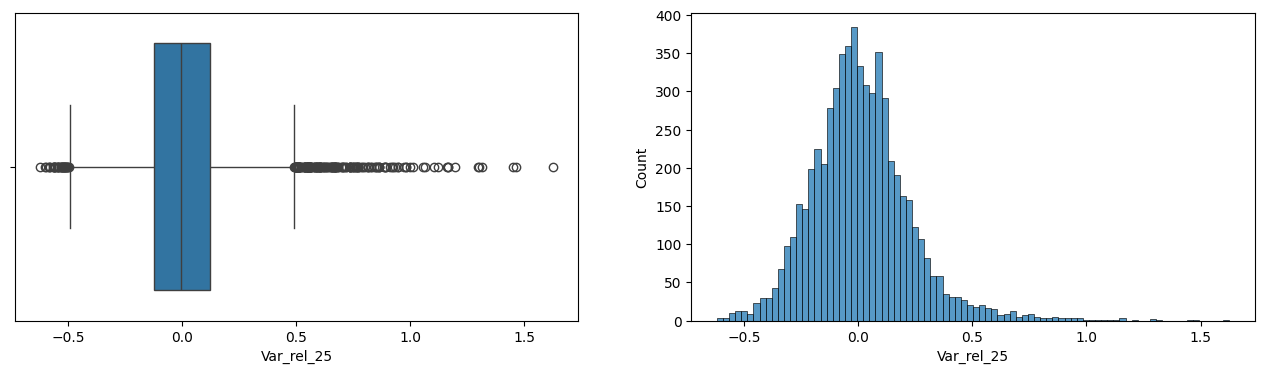

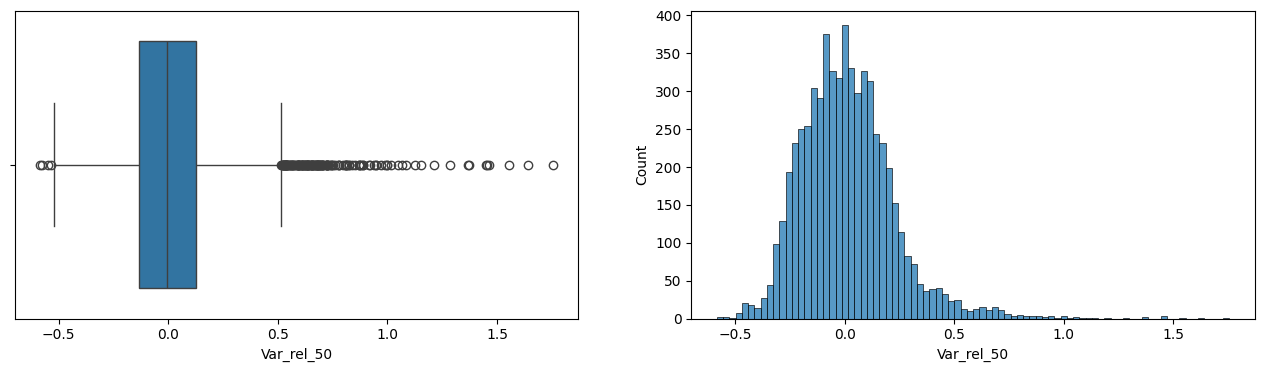

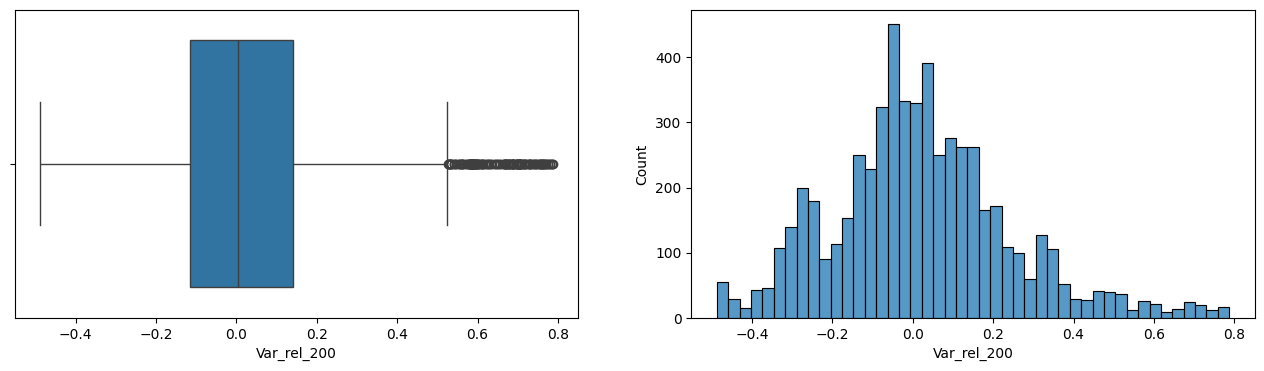

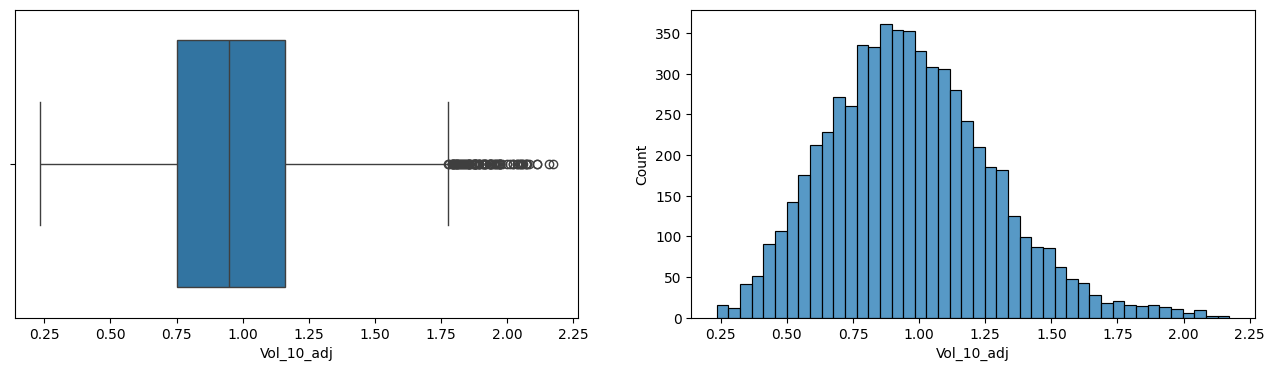

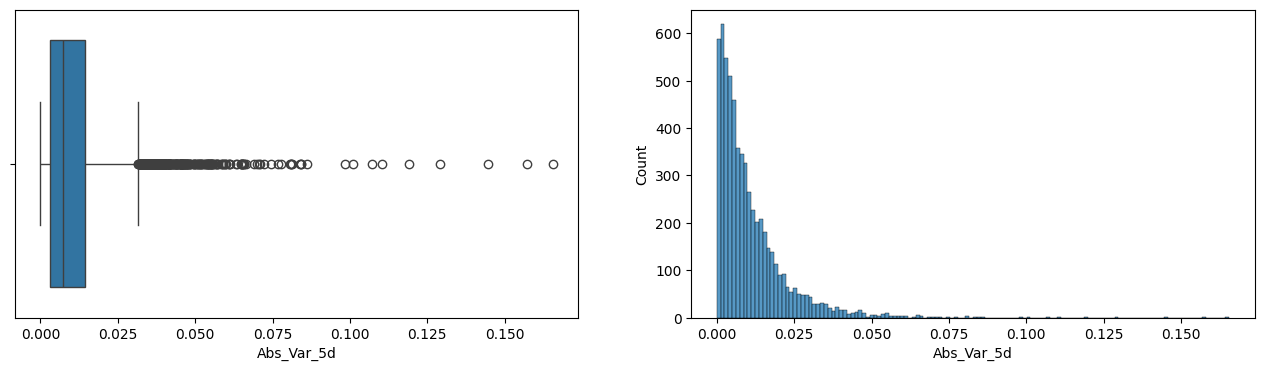

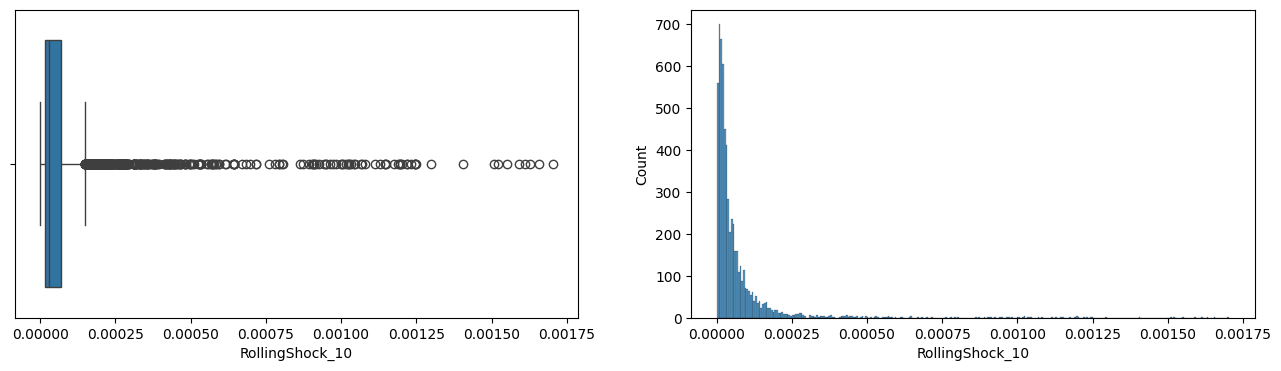

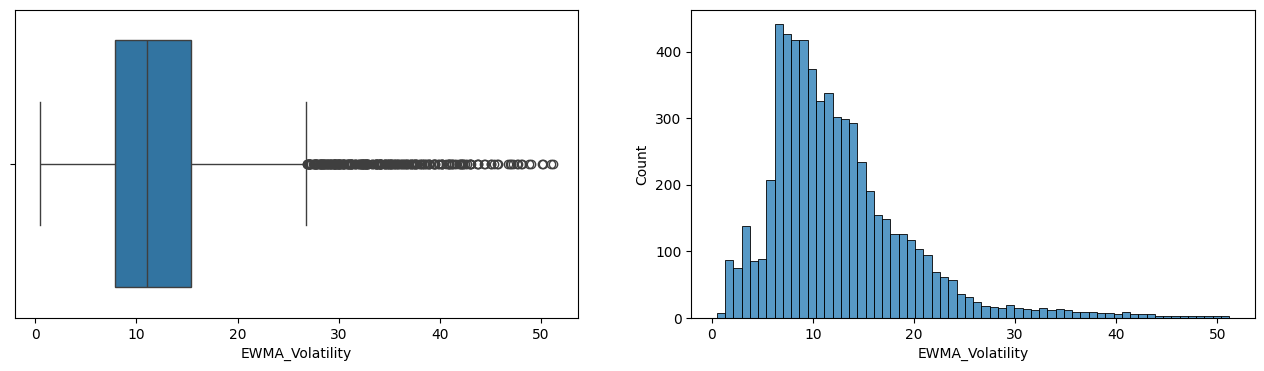

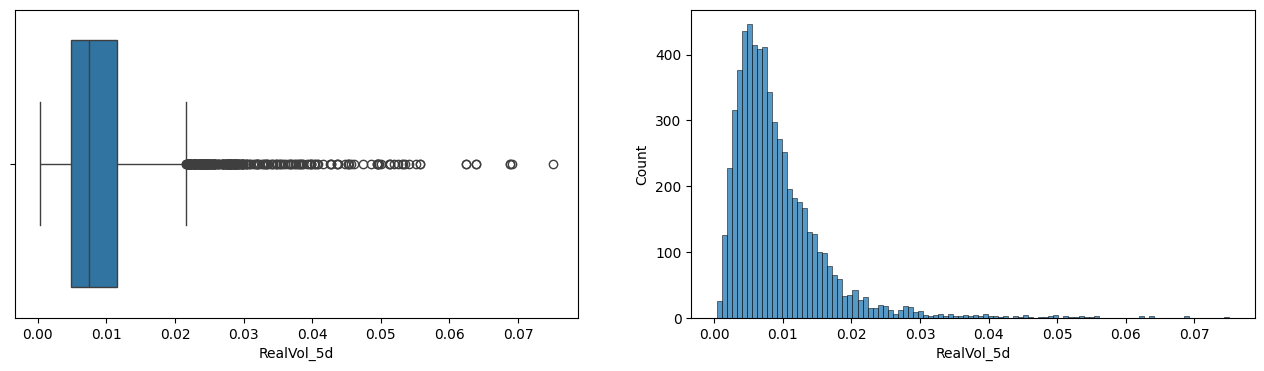

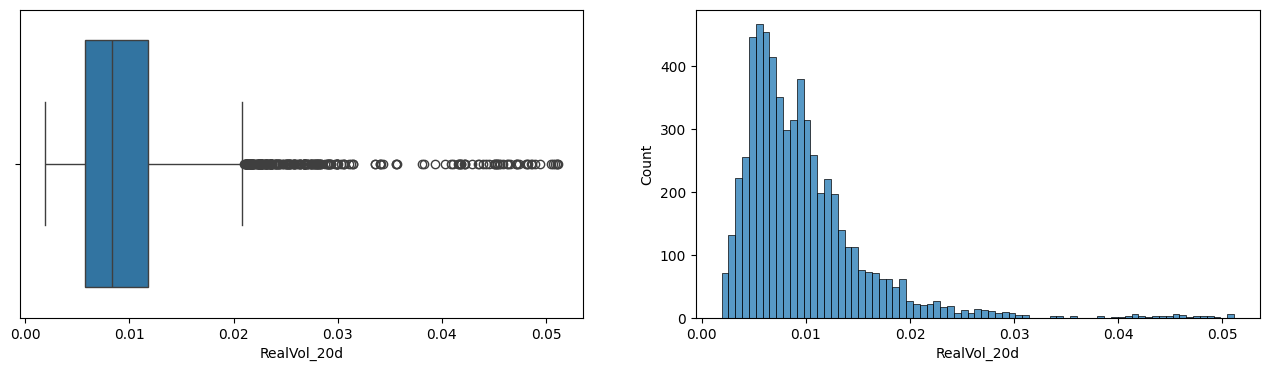

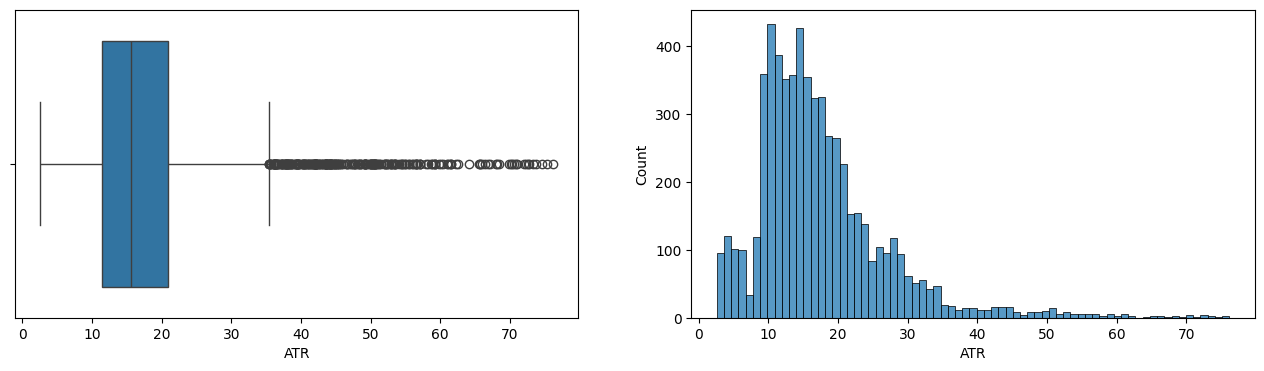

In [13]:
for x in var_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_var[x], ax=ax1)
  sns.histplot(x=train_var[x], ax=ax2)
  plt.show()


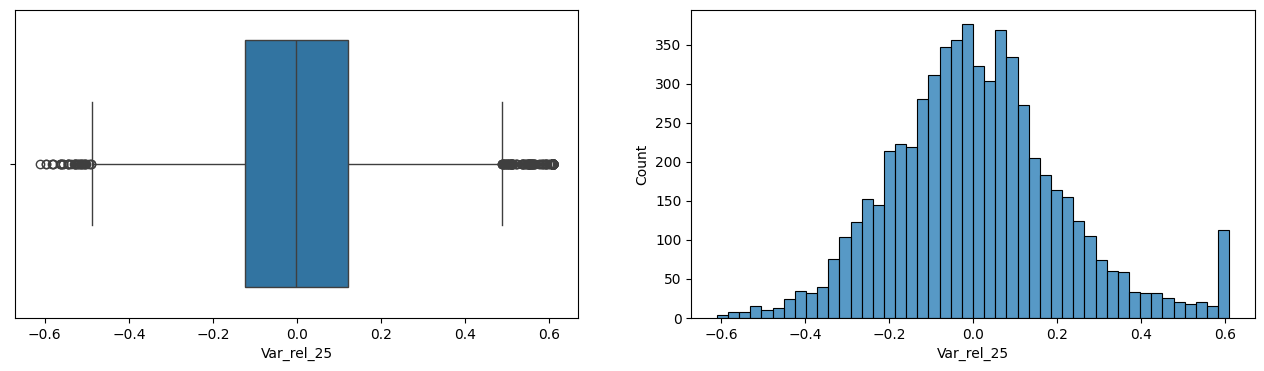

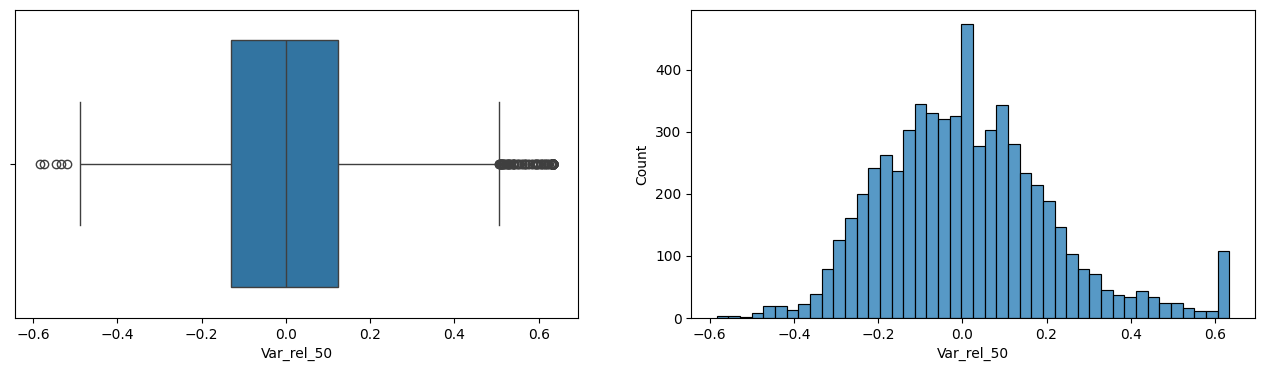

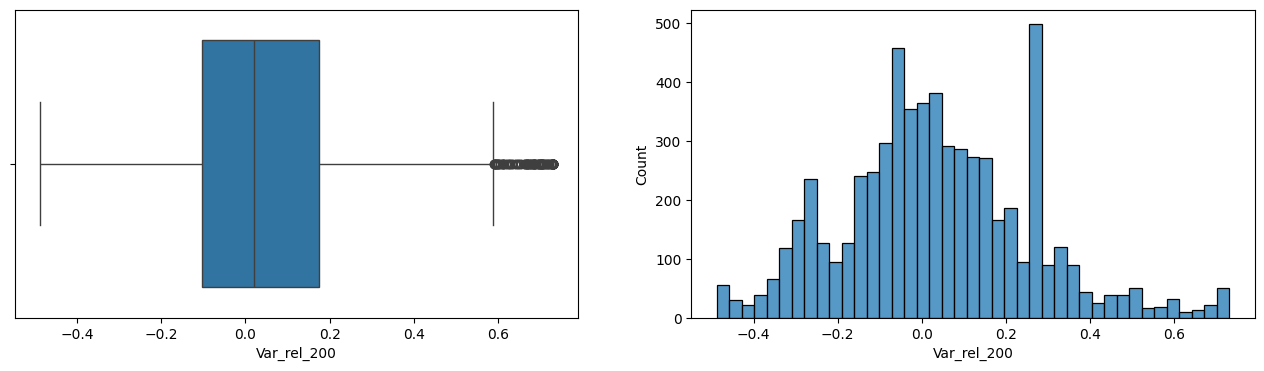

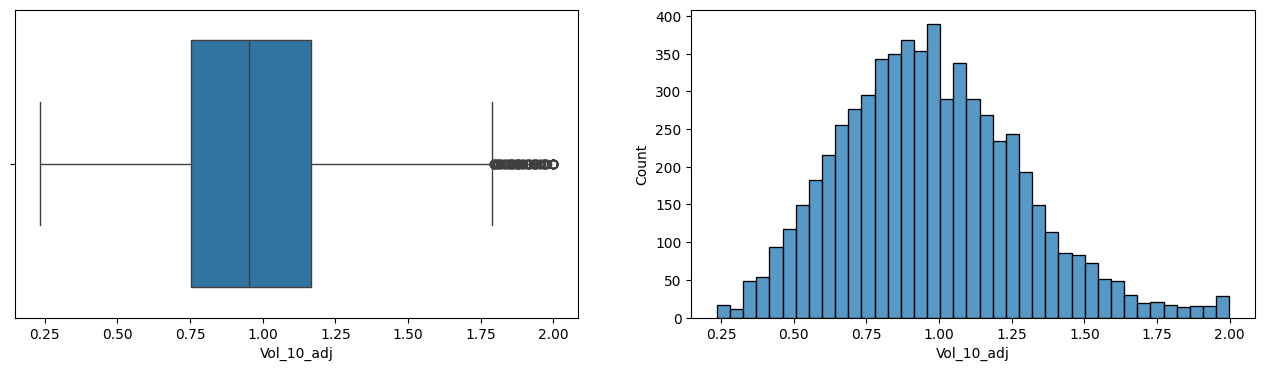

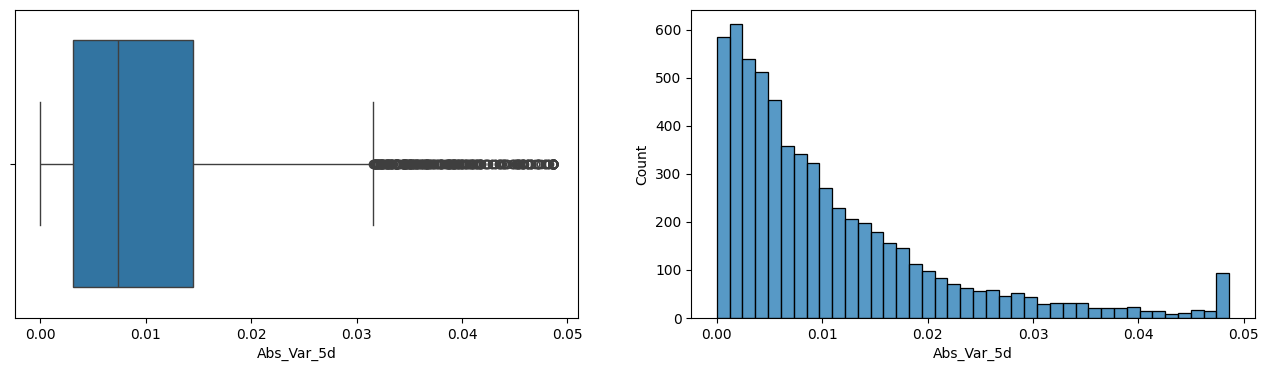

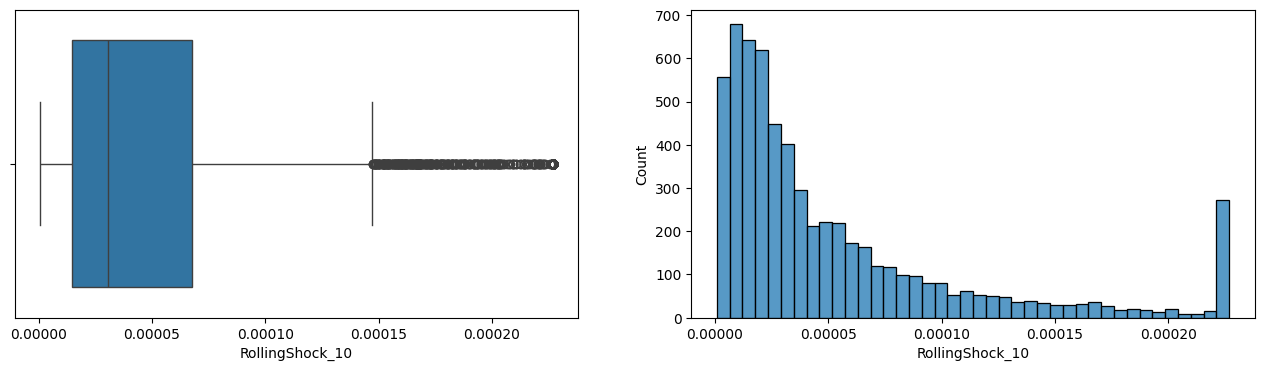

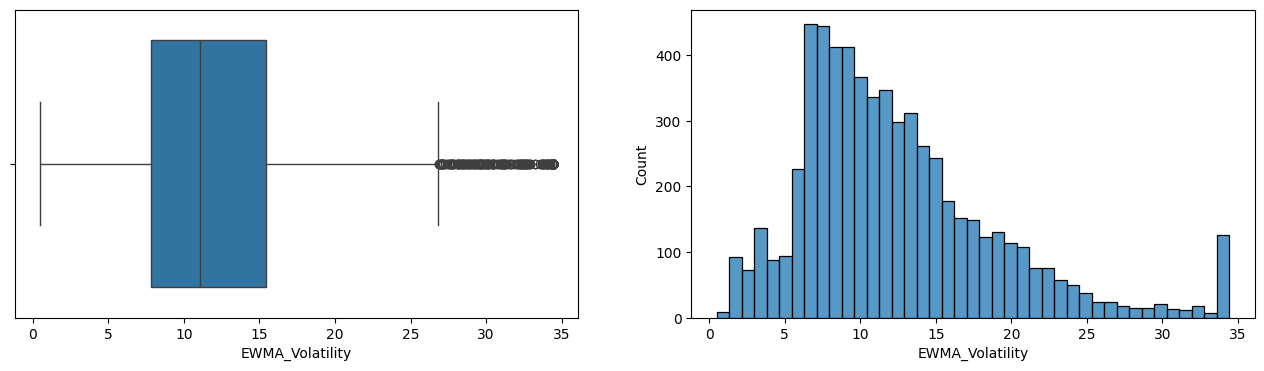

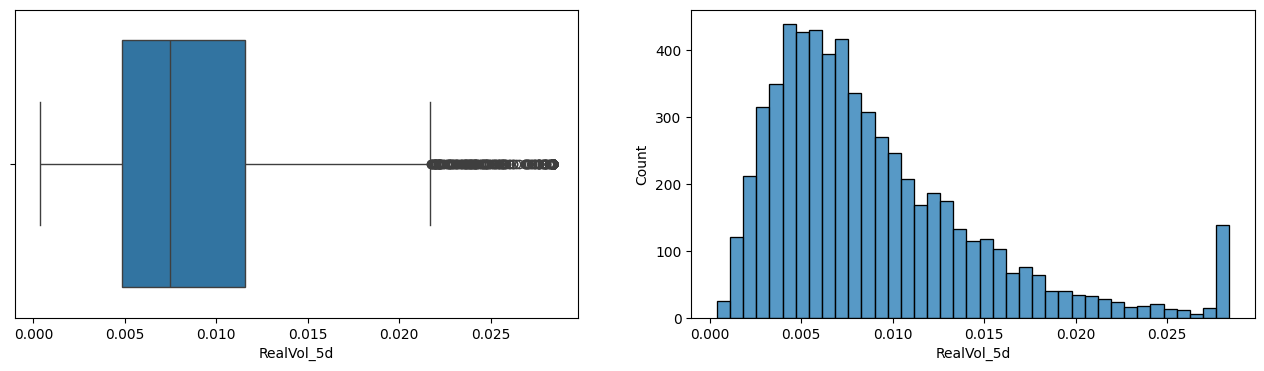

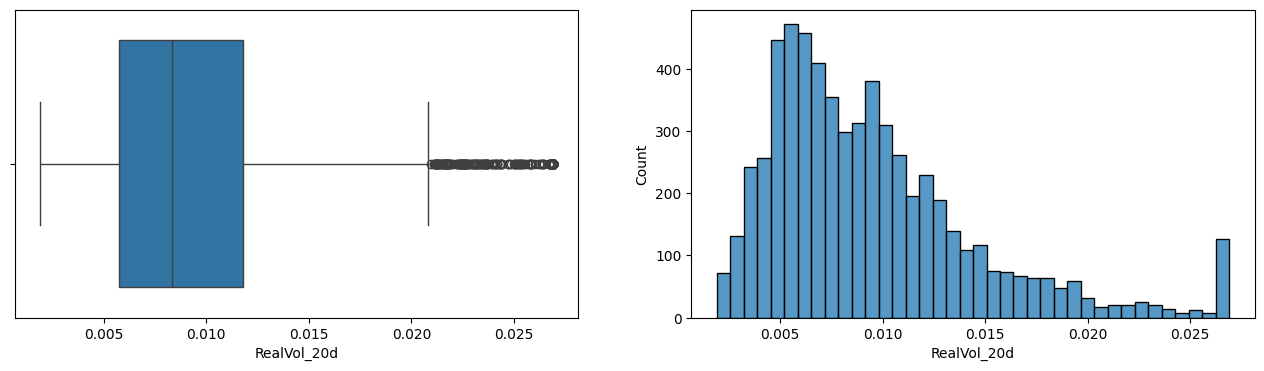

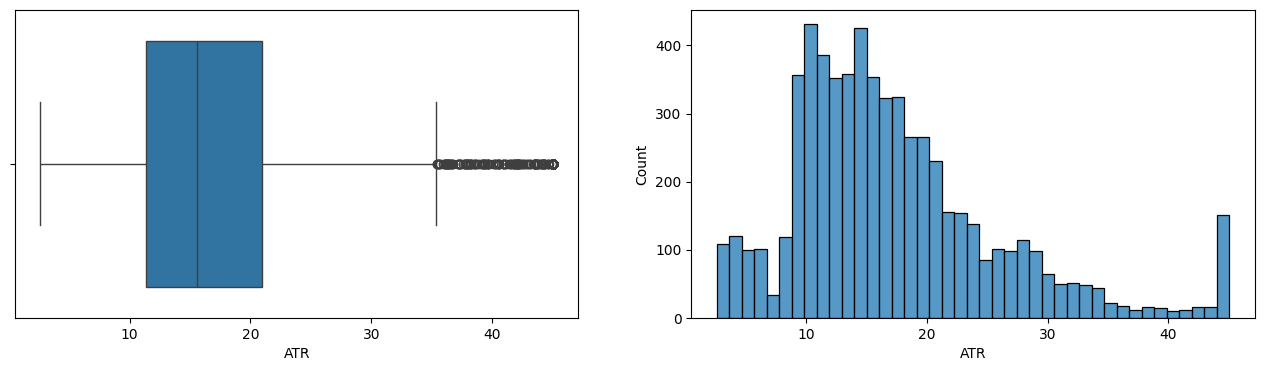

In [14]:
train_var = back_lineal_foward(train_var)
test_var = back_lineal_foward(test_var)

# Aplicar Winsorizer
winsor_2 = Winsorizer(
    capping_method='iqr',
    tail='both',
    fold=2,
    variables=['Var_rel_25', 'Var_rel_50', 'Var_rel_200', 'Vol_10_adj']
)

train_var = winsor_2.fit_transform(train_var)
test_var = winsor_2.transform(test_var)


winsor_3 = Winsorizer(
    capping_method='iqr',
    tail='right',
    fold=3,
    variables=['Abs_Var_5d', 'RollingShock_10']
)

train_var = winsor_3.fit_transform(train_var)
test_var = winsor_3.transform(test_var)

winsor_2_5 = Winsorizer(
    capping_method='iqr',
    tail='right',
    fold=2.5,
    variables=['EWMA_Volatility', 'RealVol_5d', 'RealVol_20d', 'ATR']
)

train_var = winsor_2_5.fit_transform(train_var)
test_var = winsor_2_5.transform(test_var)

for x in var_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_var[x], ax=ax1)
  sns.histplot(x=train_var[x], ax=ax2)
  plt.show()


## **2. Variables de Momento y Shocks Recientes**

**Objetivo:** Miden la dirección y fuerza de movimientos recientes.

* `retorno_porcentaje`, `retorno_porcentaje_5`, `retorno_porcentaje_10`, etc.
* `SquaredRet_1d`, `AbsRet_1d`
* `Close_rel_25`, `Close_rel_50`, `Close_rel_200`

Permiten capturar si el activo viene cayendo fuertemente o si muestra signos de reversión, lo cual puede anticipar un drawdown o recuperación.


In [15]:
train_dir = train_var.copy()
test_dir = test_var.copy()

def calcular_retornos(df, days):
  df = df.copy()
  for d in days:
    df[f"retorno_porcentaje_{d}"] = df["retorno_porcentaje"].shift(d)
  return df

train_dir = calcular_retornos(train_dir, [5, 10])
test_dir = calcular_retornos(test_dir, [5, 10])

def calc_return_shocks(df):
    df = df.copy()
    df["SquaredRet_1d"] = df["retorno_porcentaje"].shift(1) ** 2
    df["AbsRet_1d"] = df["retorno_porcentaje"].shift(1).abs()
    return df

train_dir = calc_return_shocks(train_dir)
test_dir = calc_return_shocks(test_dir)

def relative_close (df, windows):
  df = df.copy()
  for w in windows:
    pmc = df['Close'].rolling(window=w).mean()
    df[f"Close_rel_{w}"] = (df["Close"] - pmc)/pmc
  return df

train_dir = relative_close(train_dir, [25, 50, 200])
test_dir = relative_close(test_dir, [25, 50, 200])


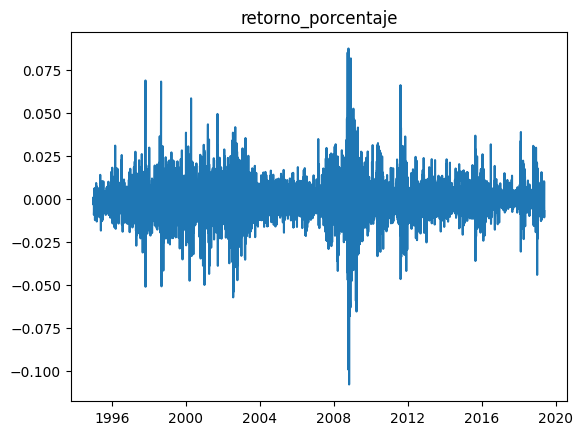

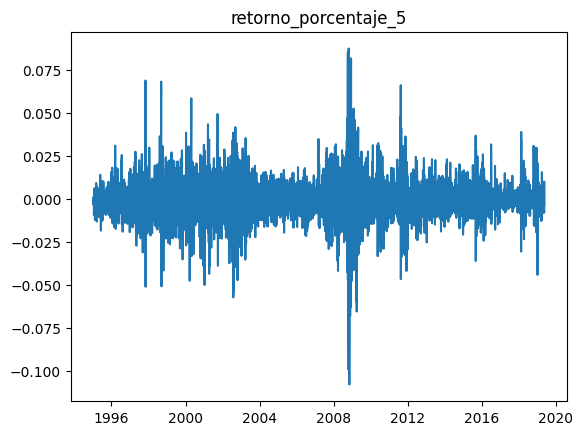

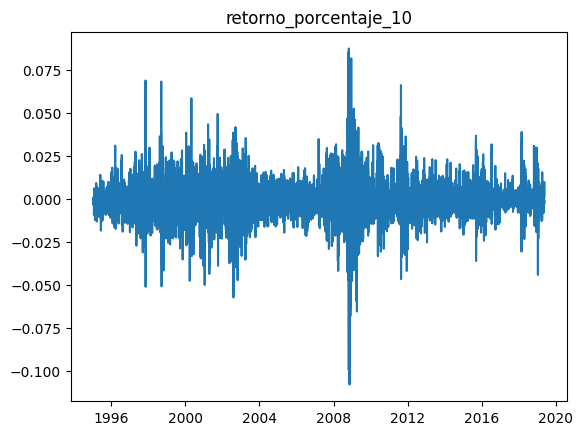

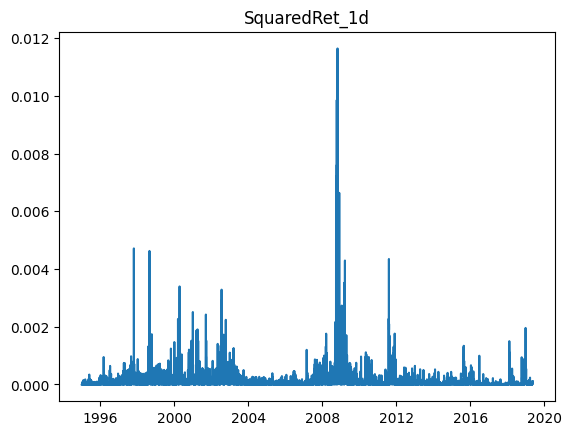

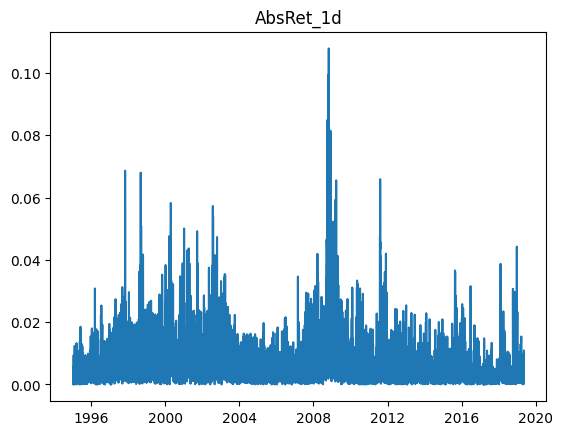

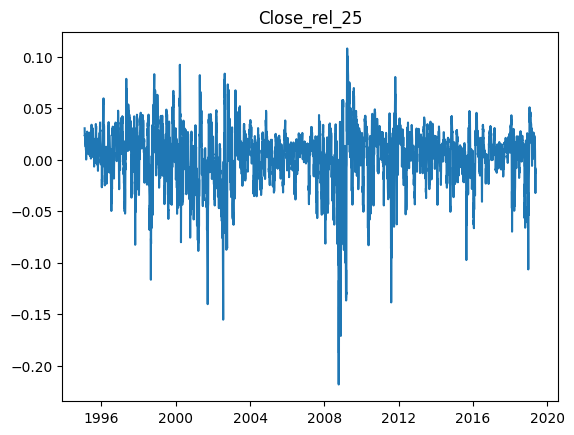

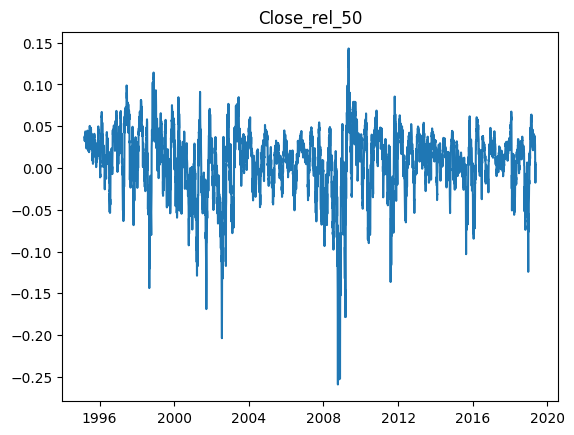

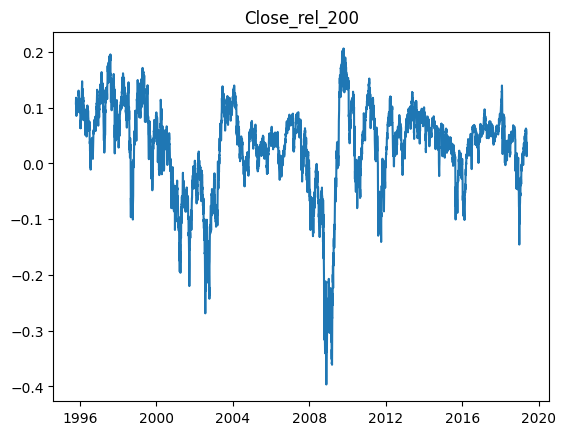

In [16]:
dir_features = ['retorno_porcentaje', 'retorno_porcentaje_5', 'retorno_porcentaje_10', 'SquaredRet_1d', 'AbsRet_1d', 'Close_rel_25', 'Close_rel_50', 'Close_rel_200']

for var in dir_features:
  plt.plot(train_dir[var])
  plt.title(var)
  plt.show()

### Outliers y Nulos

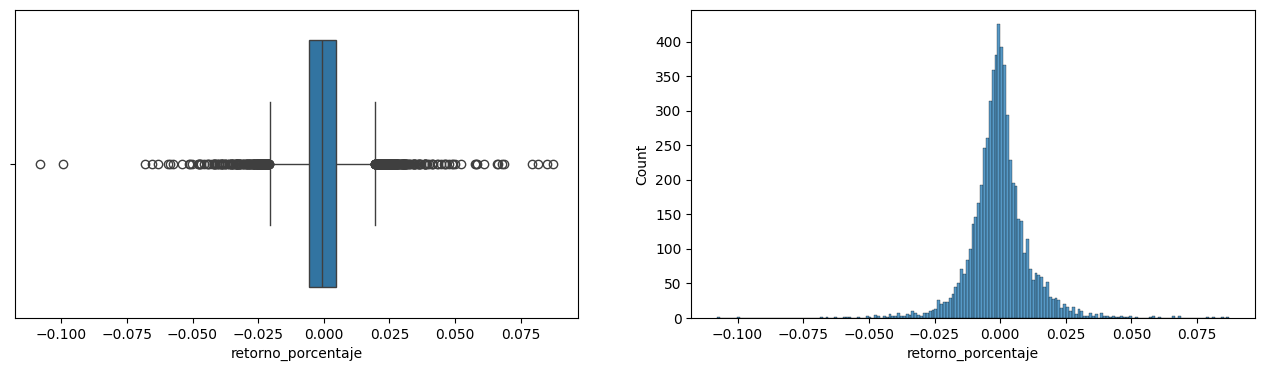

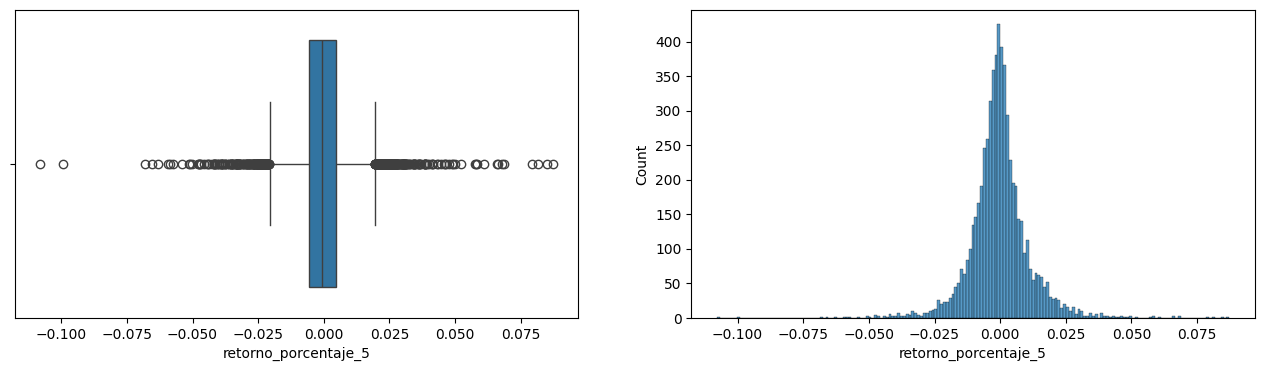

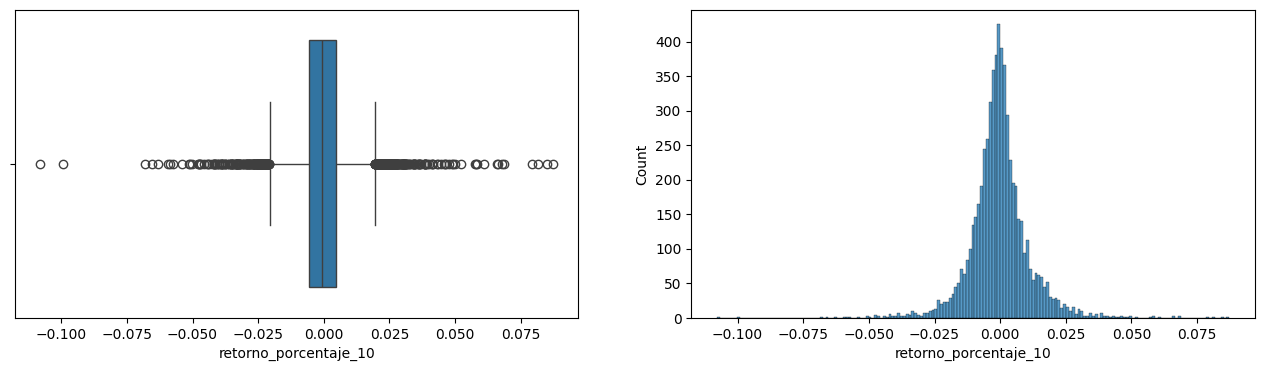

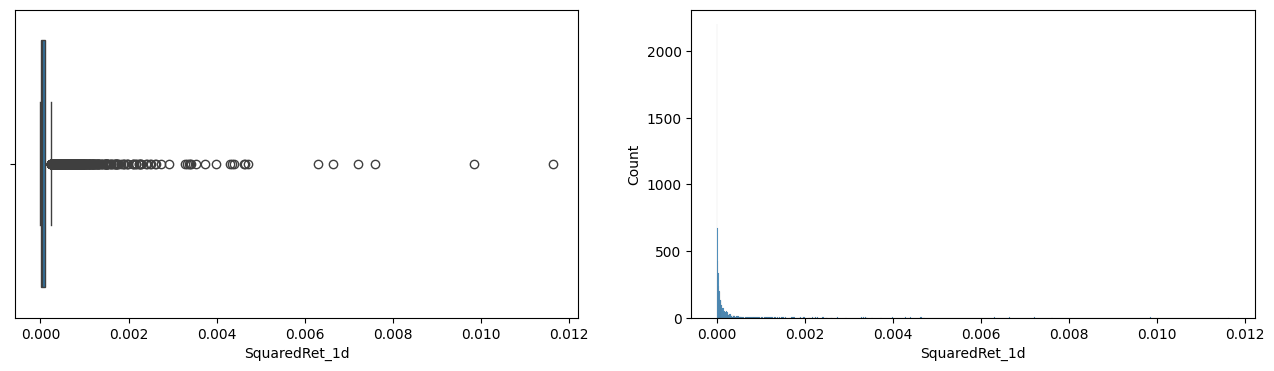

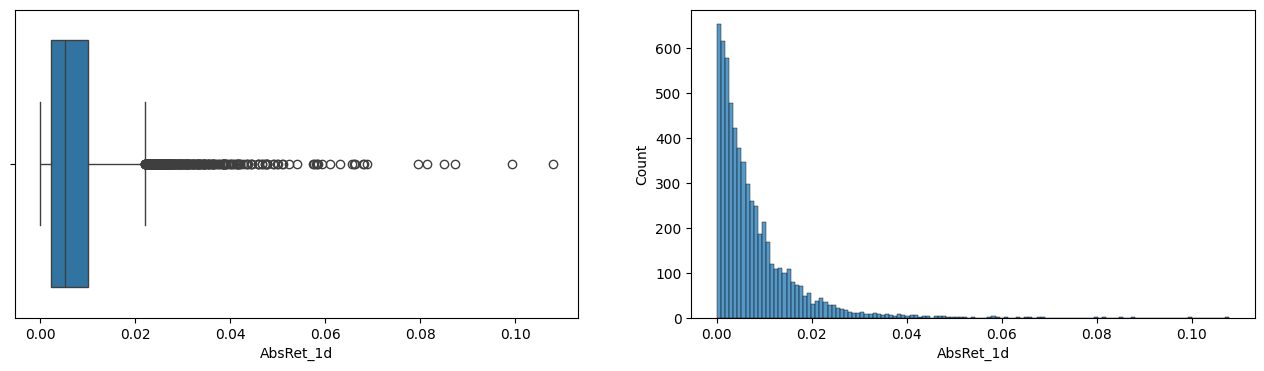

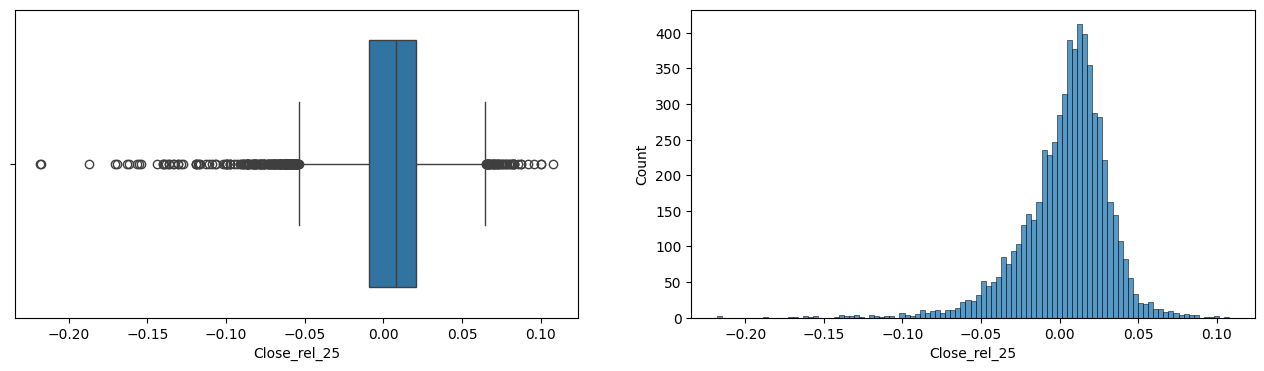

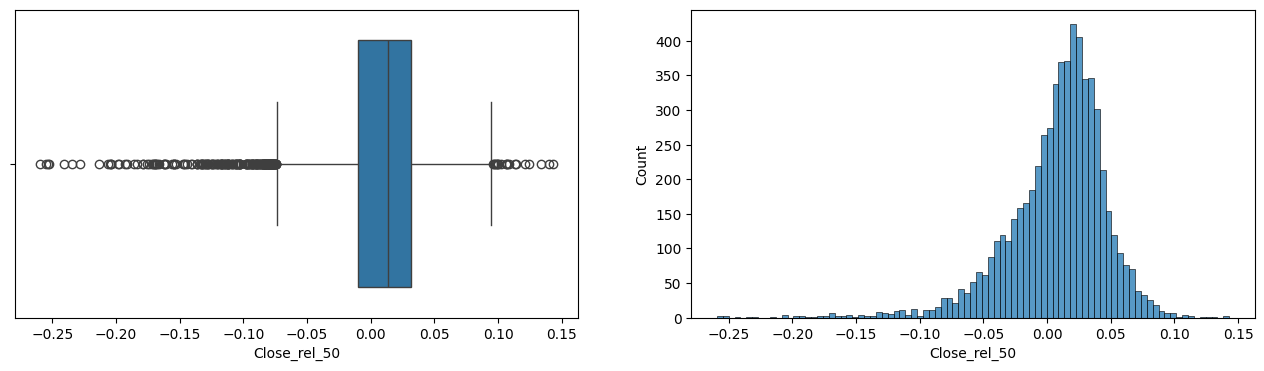

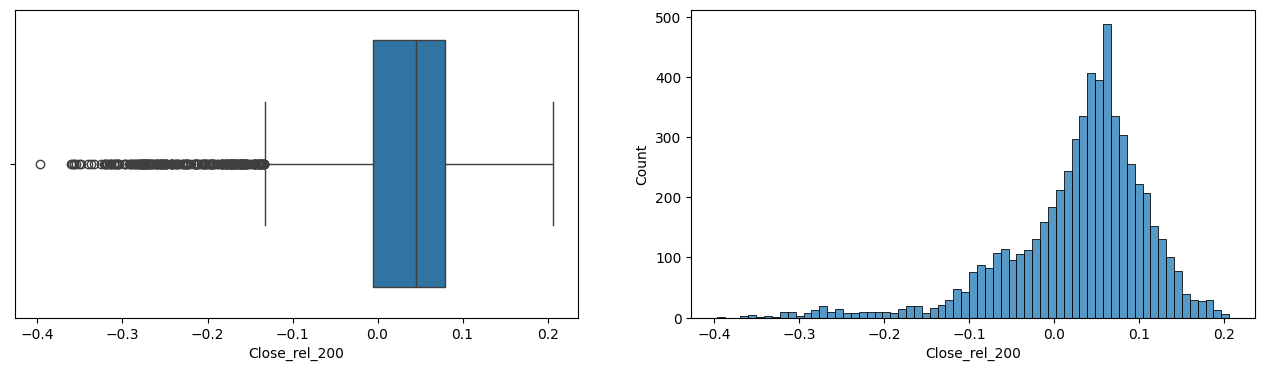

In [17]:
for x in dir_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_dir[x], ax=ax1)
  sns.histplot(x=train_dir[x], ax=ax2)
  plt.show()


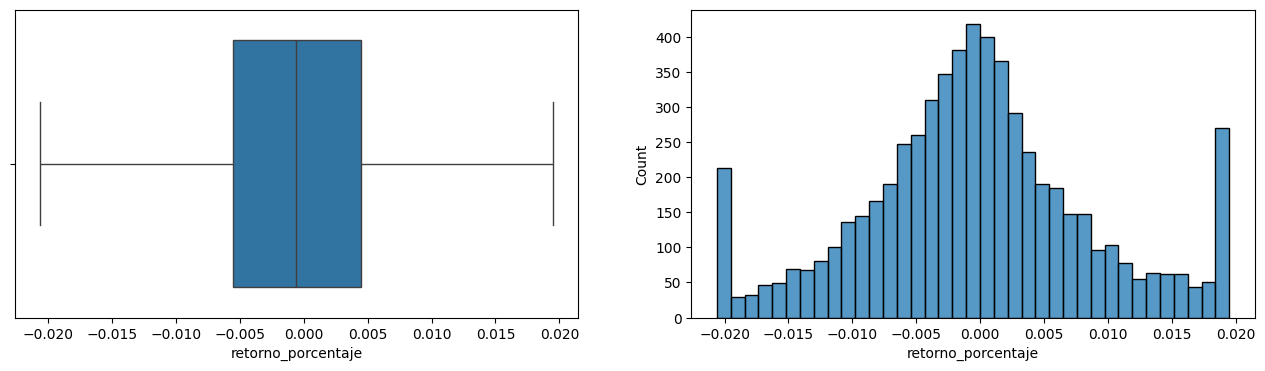

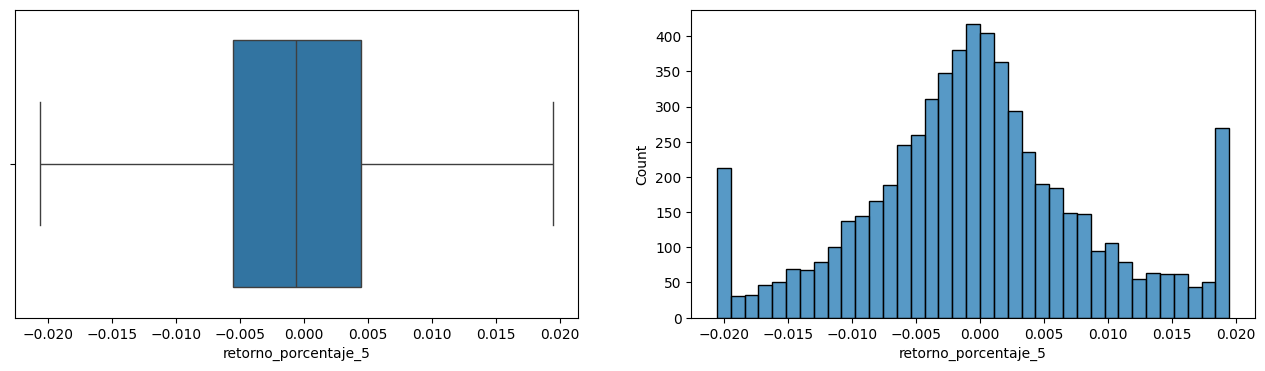

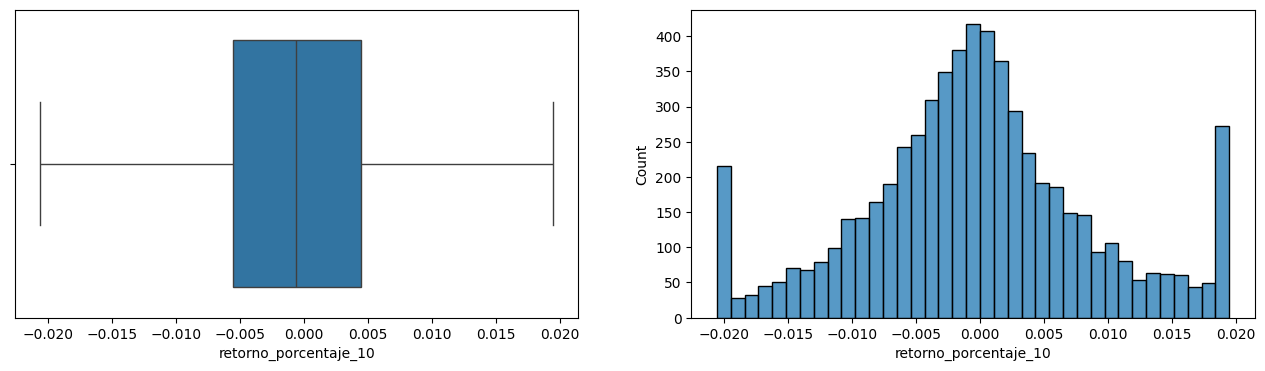

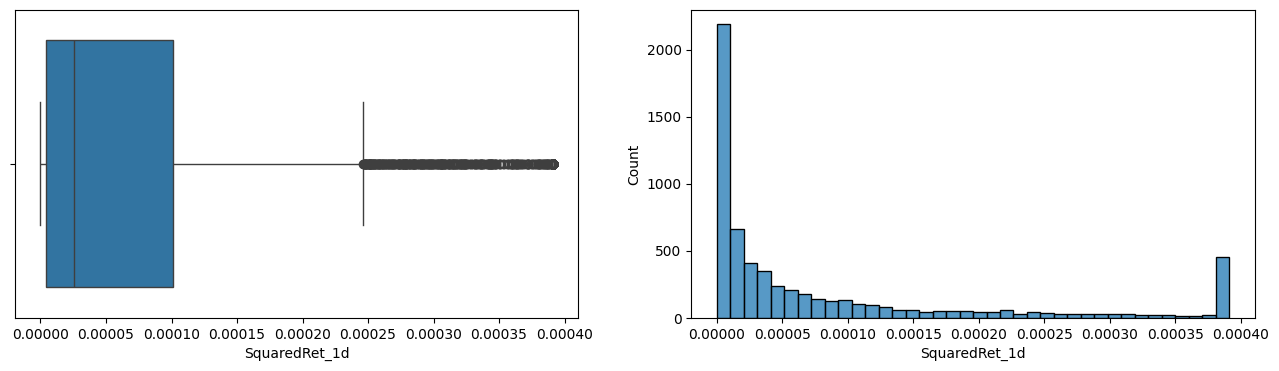

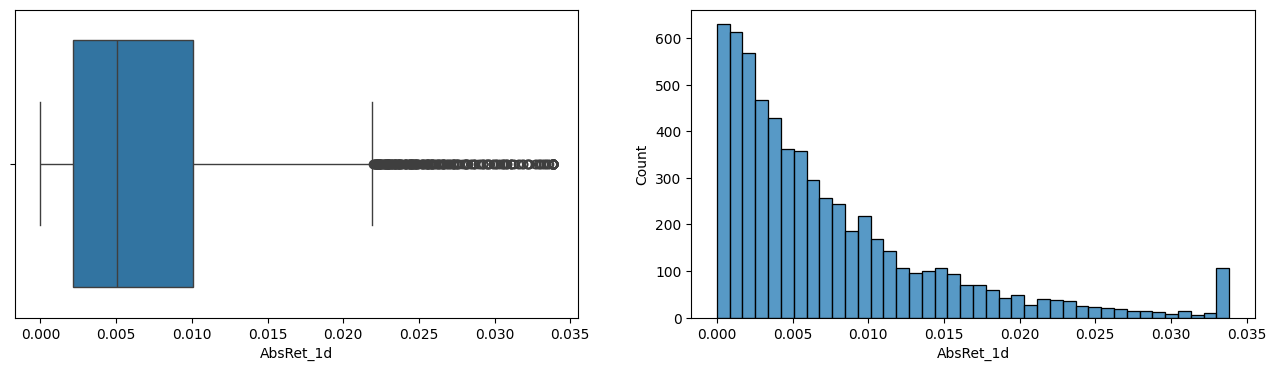

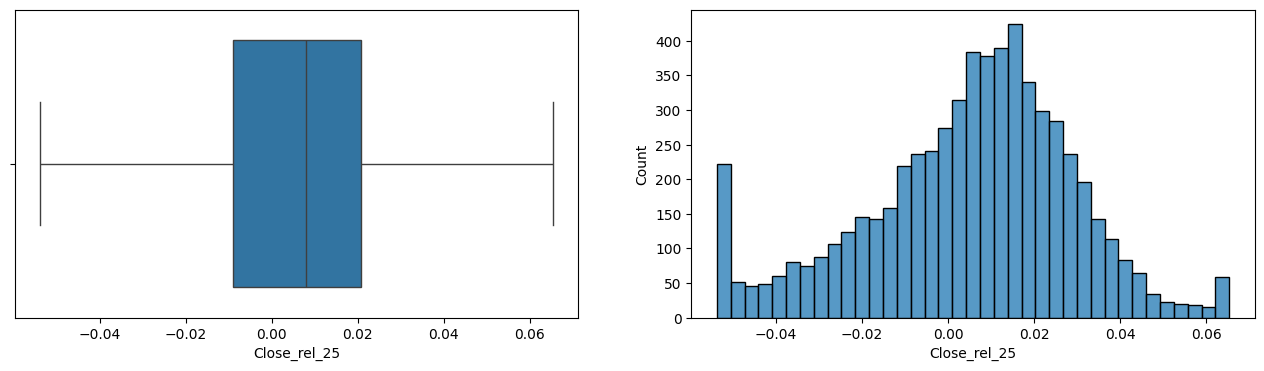

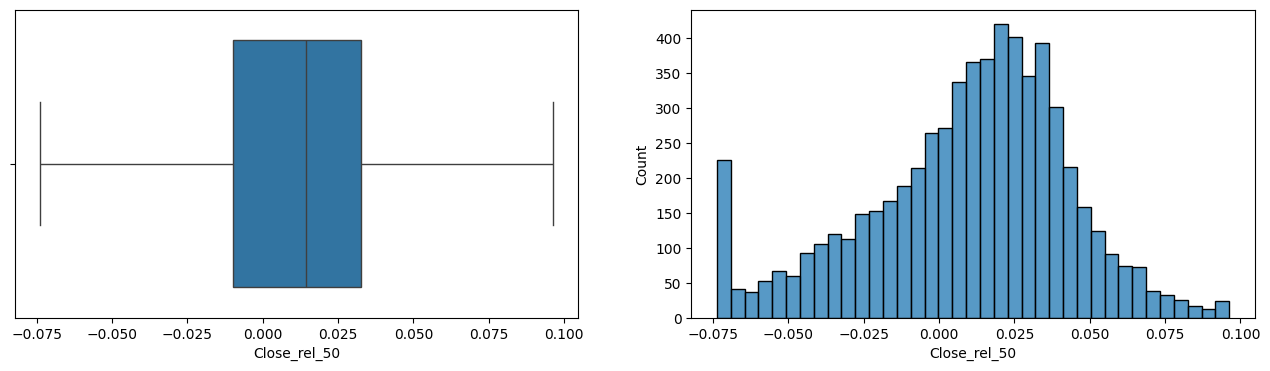

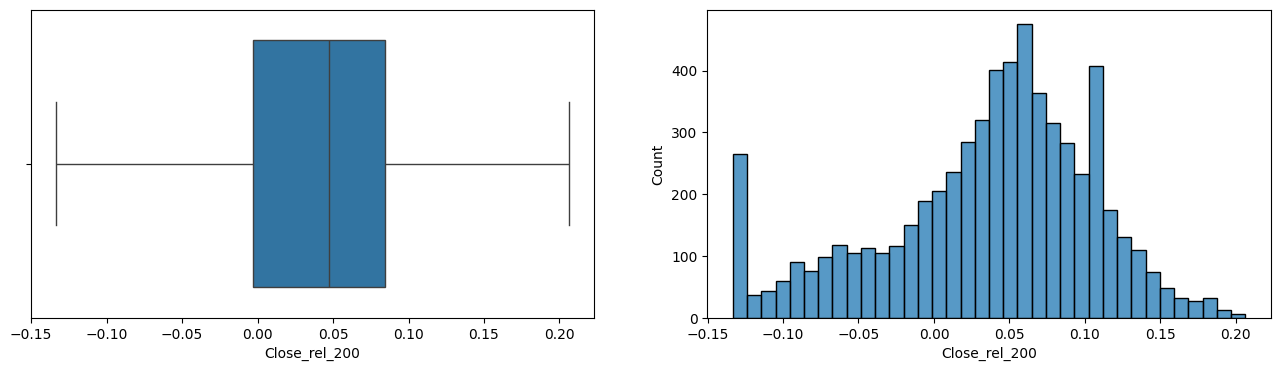

In [18]:
train_dir = back_lineal_foward(train_dir)
test_dir = back_lineal_foward(test_dir)

# Aplicar Winsorizer
winsor_1_5 = Winsorizer(
    capping_method='iqr',
    tail='both',
    fold=1.5,
    variables=['retorno_porcentaje', 'retorno_porcentaje_5', 'retorno_porcentaje_10', 'Close_rel_25', 'Close_rel_50', 'Close_rel_200']
)

train_dir = winsor_1_5.fit_transform(train_dir)
test_dir = winsor_1_5.transform(test_dir)


winsor_3 = Winsorizer(
    capping_method='iqr',
    tail='right',
    fold=3,
    variables=['SquaredRet_1d', 'AbsRet_1d']
)

train_dir = winsor_3.fit_transform(train_dir)
test_dir = winsor_3.transform(test_dir)

for x in dir_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_dir[x], ax=ax1)
  sns.histplot(x=train_dir[x], ax=ax2)
  plt.show()


## **3. Variables de Volumen**

**Objetivo:** Reflejan actividad y presión de mercado.

* `Volume_rel_25`, `Volume_rel_50`, `Volume_rel_200`

Volúmenes altos pueden confirmar movimientos y volúmenes inusuales pueden señalar posibles eventos extremos.


In [19]:
train_vol = train_dir.copy()
test_vol = test_dir.copy()

def relative_volume (df, windows):
  df = df.copy()
  for w in windows:
    pmc = df['Volume'].rolling(window=w).mean()
    df[f"Volume_rel_{w}"] = (df["Volume"] - pmc)/pmc
  return df

train_vol = relative_volume(train_vol, [25, 50, 200])
test_vol = relative_volume(test_vol, [25, 50, 200])

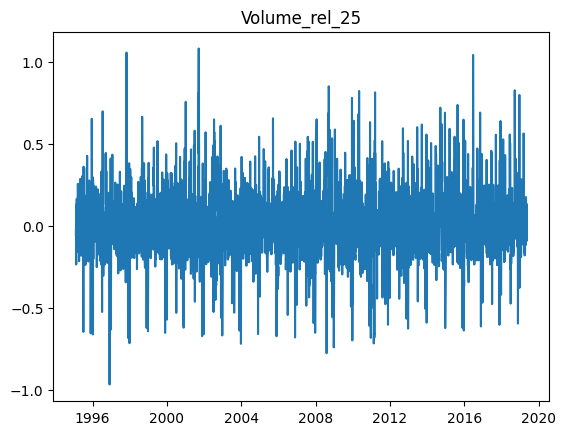

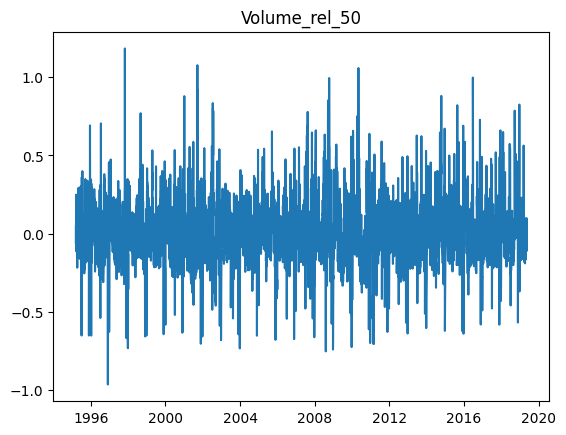

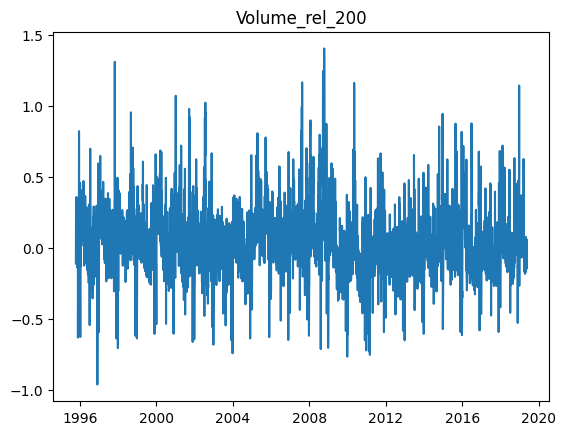

In [20]:
vol_features = ['Volume_rel_25', 'Volume_rel_50', 'Volume_rel_200']

for var in vol_features:
  plt.plot(train_vol[var])
  plt.title(var)
  plt.show()

### Outliers y Nulos

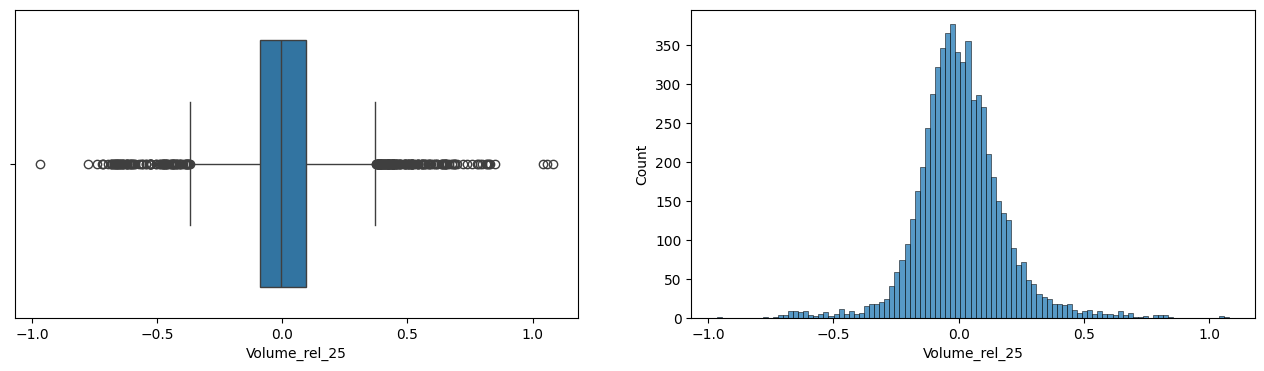

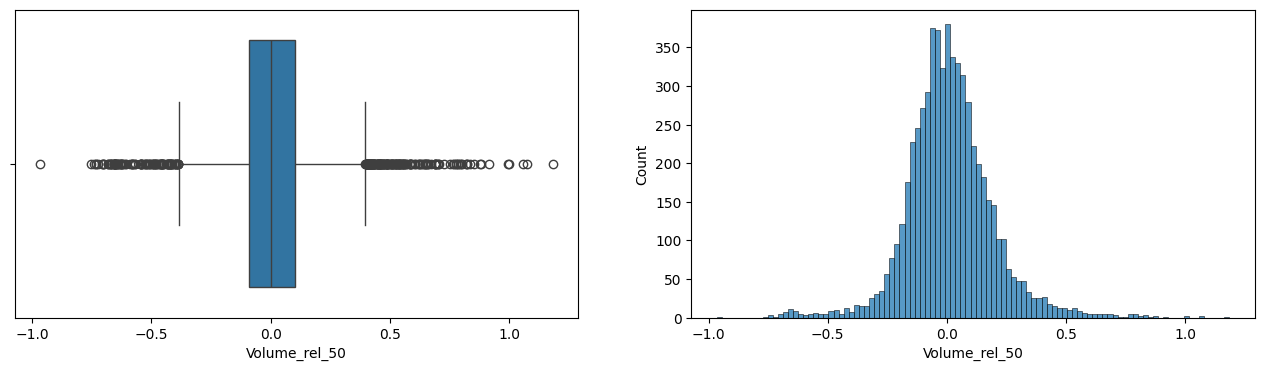

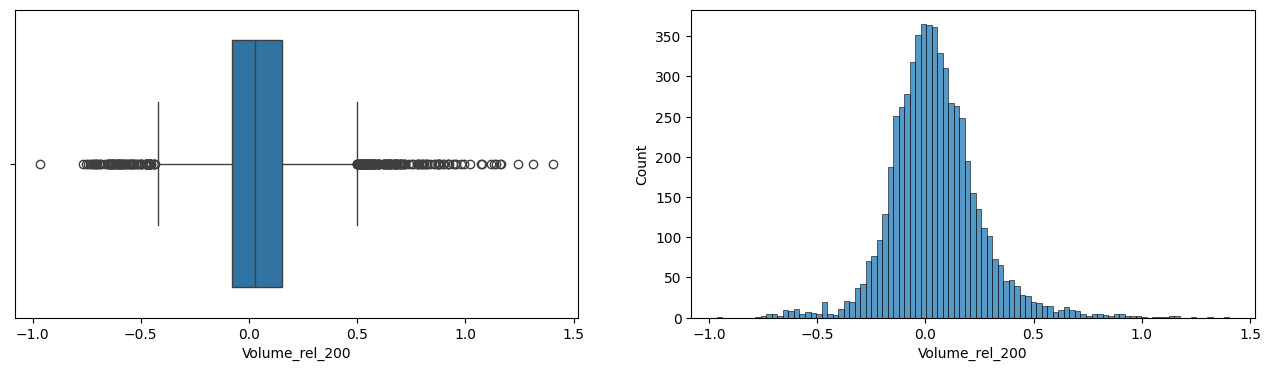

In [21]:
for x in vol_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_vol[x], ax=ax1)
  sns.histplot(x=train_vol[x], ax=ax2)
  plt.show()


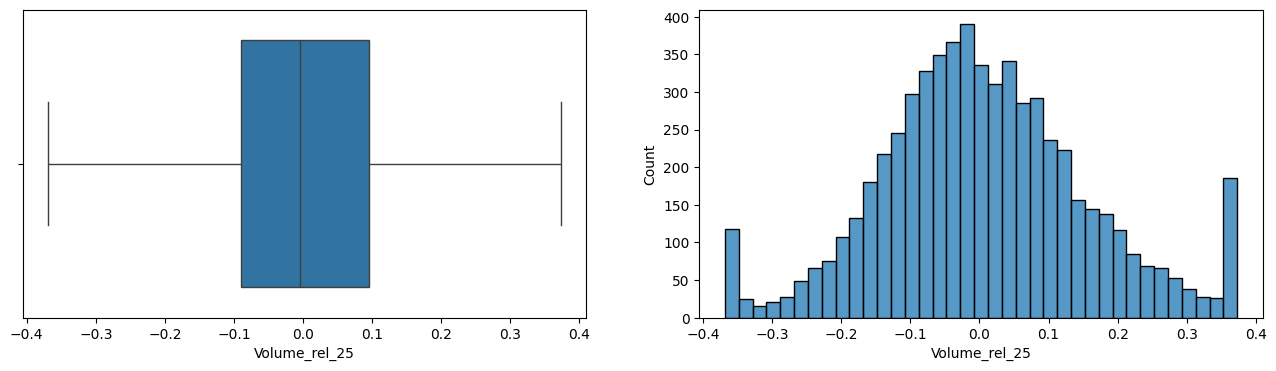

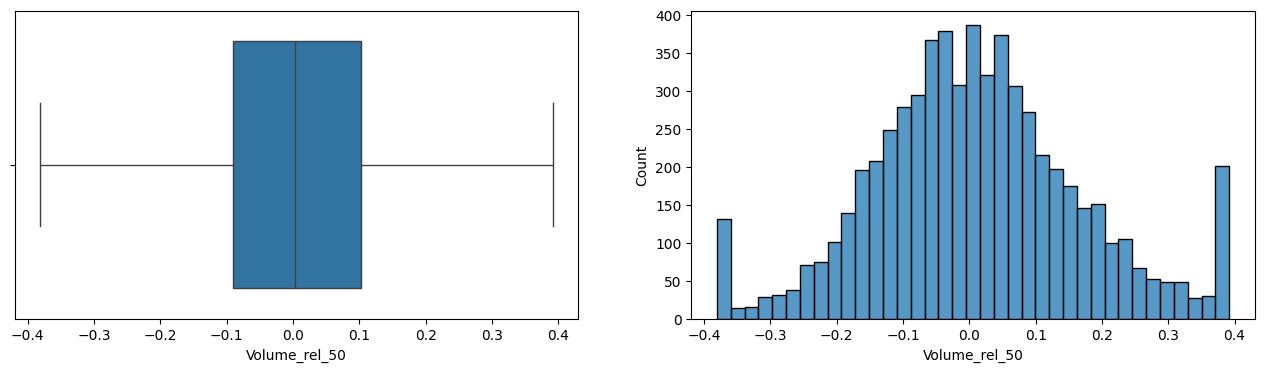

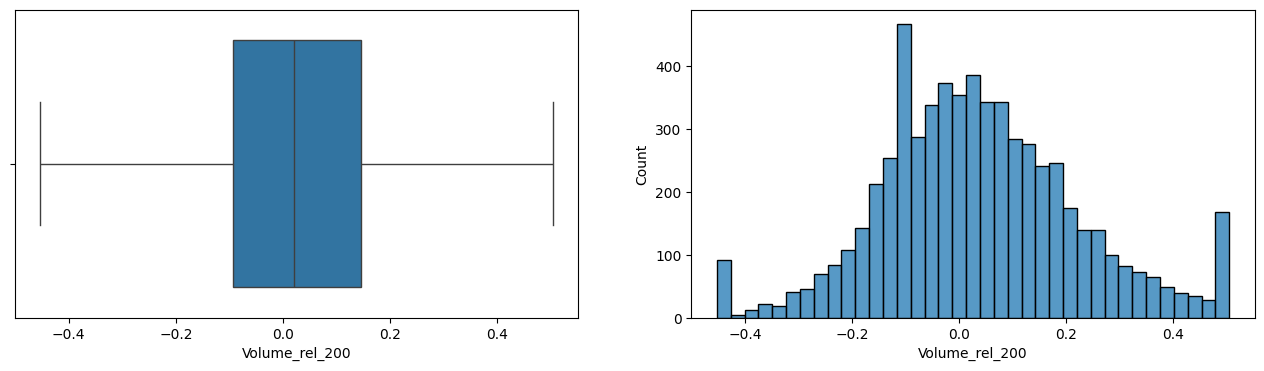

In [22]:
train_vol = back_lineal_foward(train_vol)
test_vol = back_lineal_foward(test_vol)

# Aplicar Winsorizer
winsor_1_5 = Winsorizer(
    capping_method='iqr',
    tail='both',
    fold=1.5,
    variables=['Volume_rel_25', 'Volume_rel_50', 'Volume_rel_200']
)

train_vol = winsor_1_5.fit_transform(train_vol)
test_vol = winsor_1_5.transform(test_vol)

for x in vol_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_vol[x], ax=ax1)
  sns.histplot(x=train_vol[x], ax=ax2)
  plt.show()


## **4. Variables de Forma de la Distribución (Colas)**

**Objetivo:** Capturan propiedades no normales de los retornos que pueden indicar riesgo extremo.

* `Skew_rel_50` (asimetría relativa)
* `Kurtosis_rel_50` (curtosis relativa)

Estos momentos superiores ayudan a detectar la presencia de sesgos y eventos raros (colas pesadas), muy relevantes para drawdowns.


In [23]:
train_tail = train_vol.copy()
test_tail = test_vol.copy()

def relative_skew(df):
  df = df.copy()
  skew = df["retorno_porcentaje"].rolling(window=50).skew()
  pmc = skew.rolling(window=50).min()
  df[f"Skew_rel_{50}"] = (skew - pmc)/pmc
  return df

train_tail = relative_skew(train_tail)
test_tail = relative_skew(test_tail)

def realtive_kurtosis(df):
  df = df.copy()
  kurtosis = df["retorno_porcentaje"].rolling(window=50).kurt()
  pmc = kurtosis.rolling(window=50).min()
  df[f"Kurtosis_rel_{50}"] = (kurtosis - pmc)/pmc
  return df

train_tail = realtive_kurtosis(train_tail)
test_tail = realtive_kurtosis(test_tail)

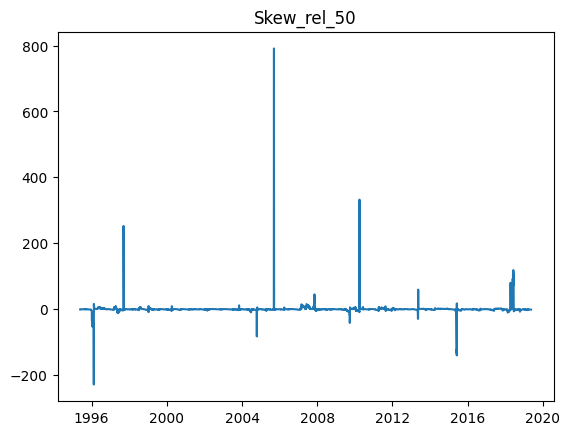

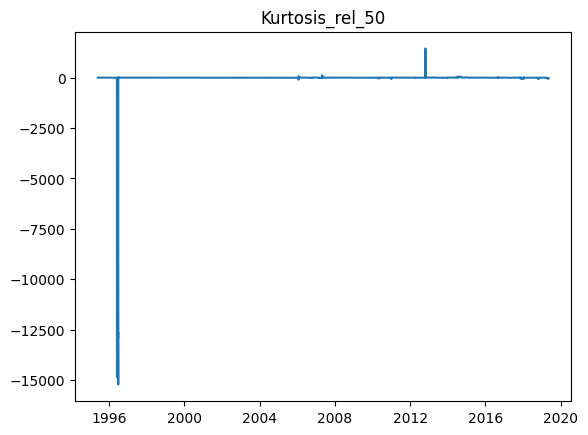

In [24]:
tail_features = ['Skew_rel_50', 'Kurtosis_rel_50']

for var in tail_features:
  plt.plot(train_tail[var])
  plt.title(var)
  plt.show()

### Outliers y Nulos

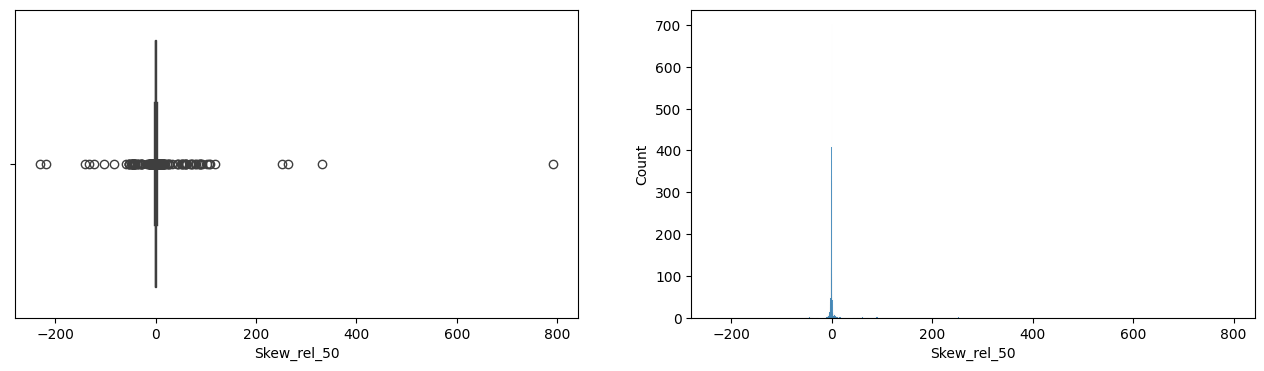

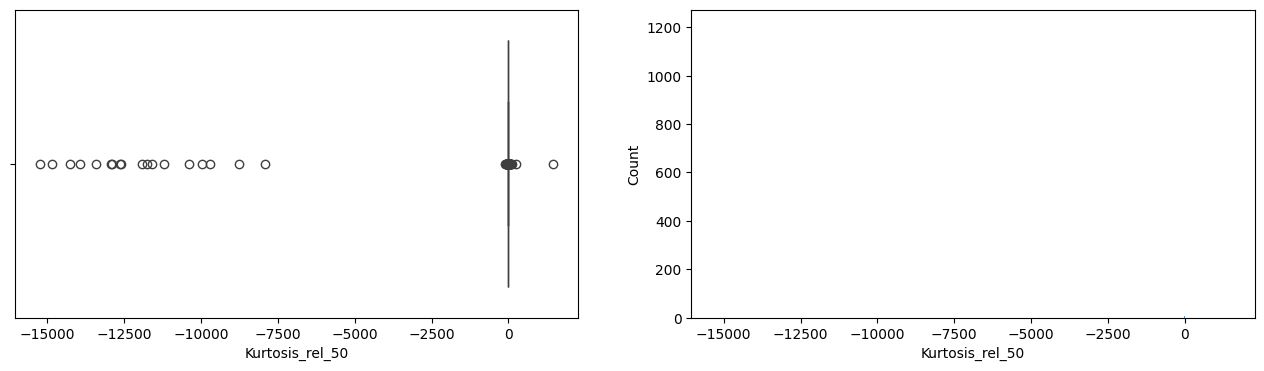

In [25]:
for x in tail_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_tail[x], ax=ax1)
  sns.histplot(x=train_tail[x], ax=ax2)
  plt.show()

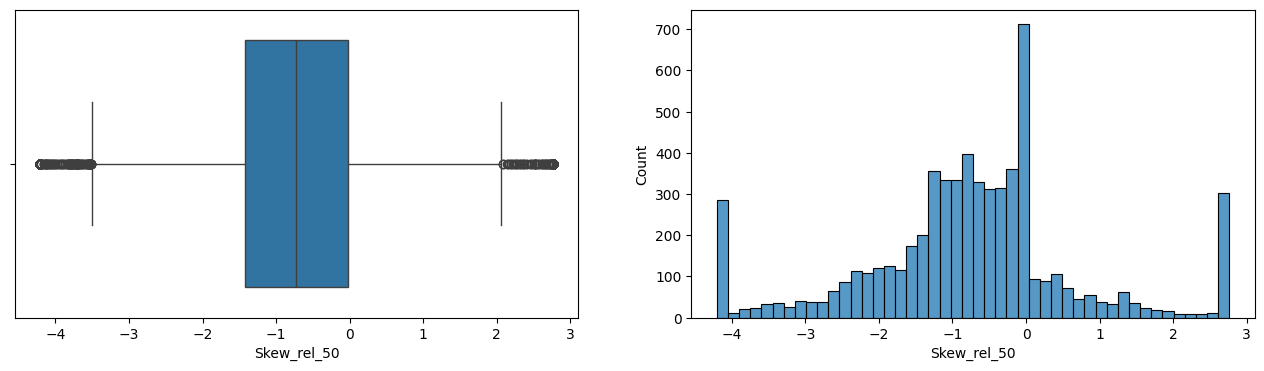

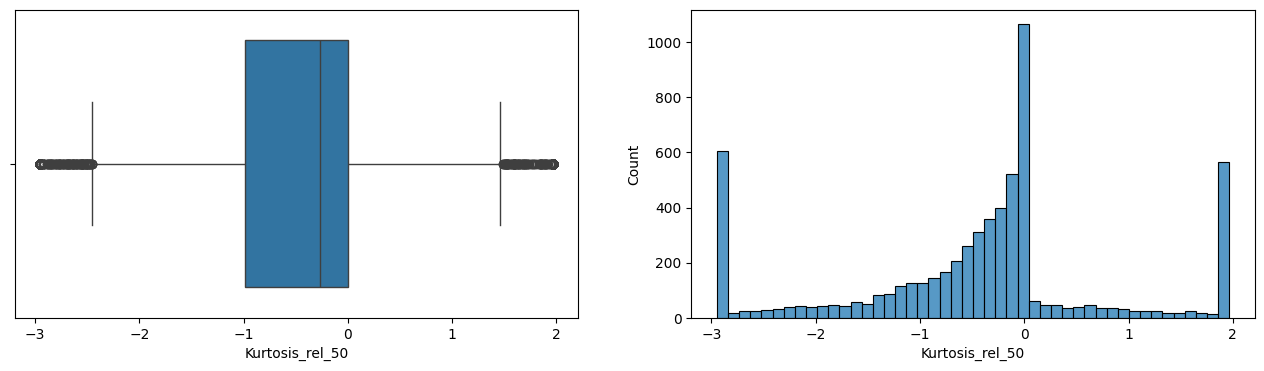

In [26]:
train_tail = back_lineal_foward(train_tail)
test_tail = back_lineal_foward(test_tail)

# Aplicar Winsorizer
winsor_2 = Winsorizer(
    capping_method='iqr',
    tail='both',
    fold=2,
    variables=['Skew_rel_50', 'Kurtosis_rel_50']
)

train_tail = winsor_2.fit_transform(train_tail)
test_tail = winsor_2.transform(test_tail)

for x in tail_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_tail[x], ax=ax1)
  sns.histplot(x=train_tail[x], ax=ax2)
  plt.show()


## **5. Variables Técnicas de Rango y Banda**

**Objetivo:** Miden la amplitud de movimiento de precios.

* `Bollinger_Width`
* `RSI`

Pueden indicar compresión o expansión inminente, lo que a menudo precede a un cambio fuerte de régimen.


In [27]:
train_tec = train_tail.copy()
test_tec = test_tail.copy()

def calc_Bollinger_Width(df, window=20, num_std=2):
    df = df.copy()
    rolling_mean = df['Close'].rolling(window=window).mean()
    rolling_std = df['Close'].rolling(window=window).std()
    df['Bollinger_Width'] = (rolling_std * num_std * 2) / rolling_mean
    return df

train_tec = calc_Bollinger_Width(train_tec)
test_tec = calc_Bollinger_Width(test_tec)

def calc_RSI(df, window=14):
    df = df.copy()
    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

train_tec = calc_RSI(train_tec)
test_tec = calc_RSI(test_tec)


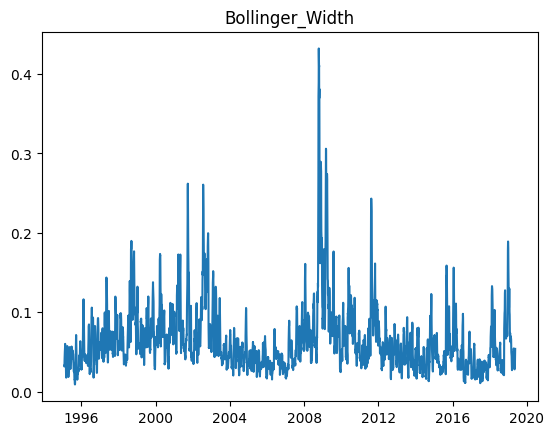

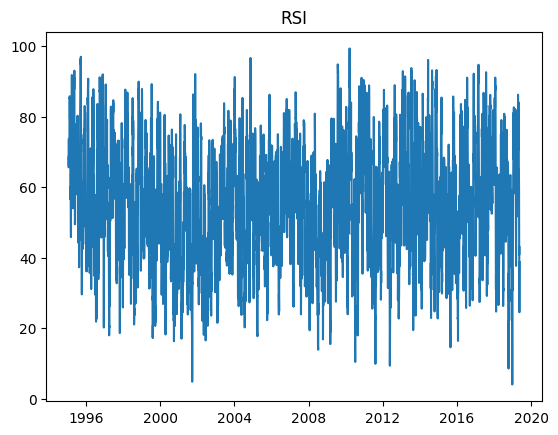

In [28]:
tec_features = ['Bollinger_Width', 'RSI']

for var in tec_features:
  plt.plot(train_tec[var])
  plt.title(var)
  plt.show()

### Outliers y Nulos

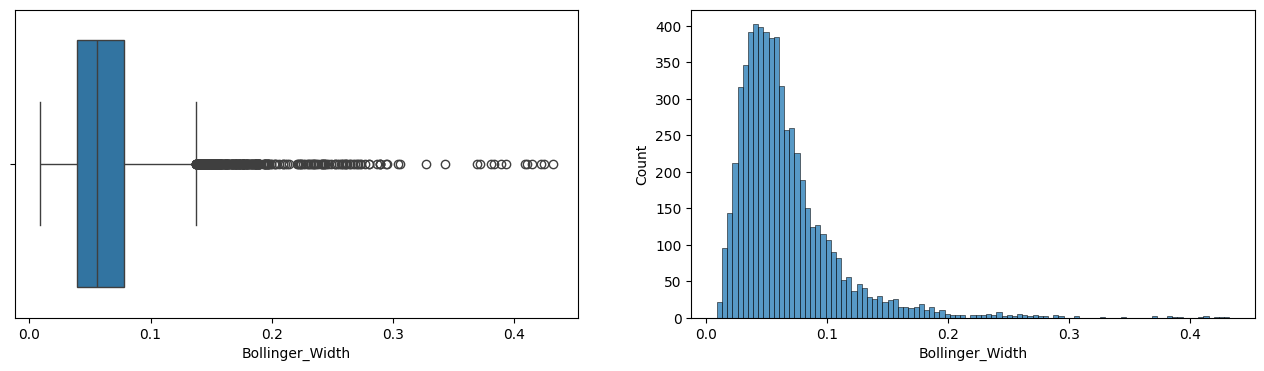

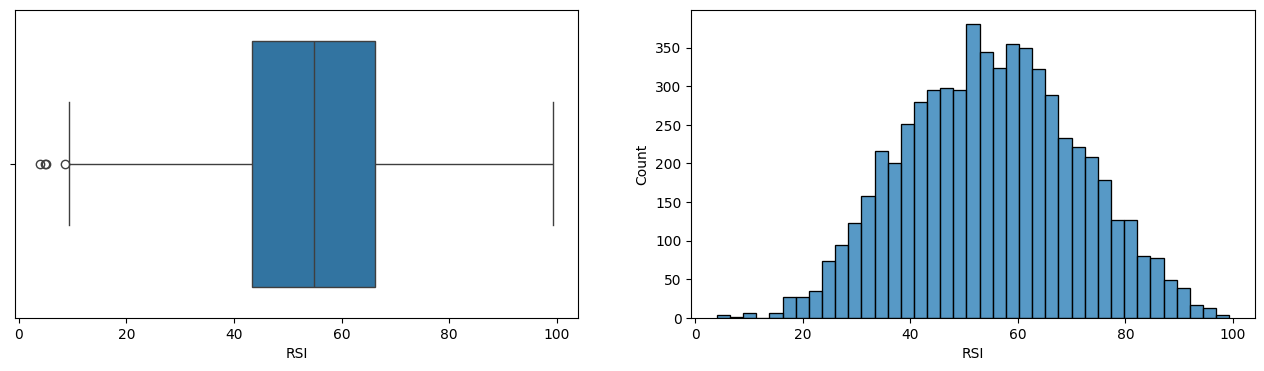

In [29]:
for x in tec_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_tec[x], ax=ax1)
  sns.histplot(x=train_tec[x], ax=ax2)
  plt.show()


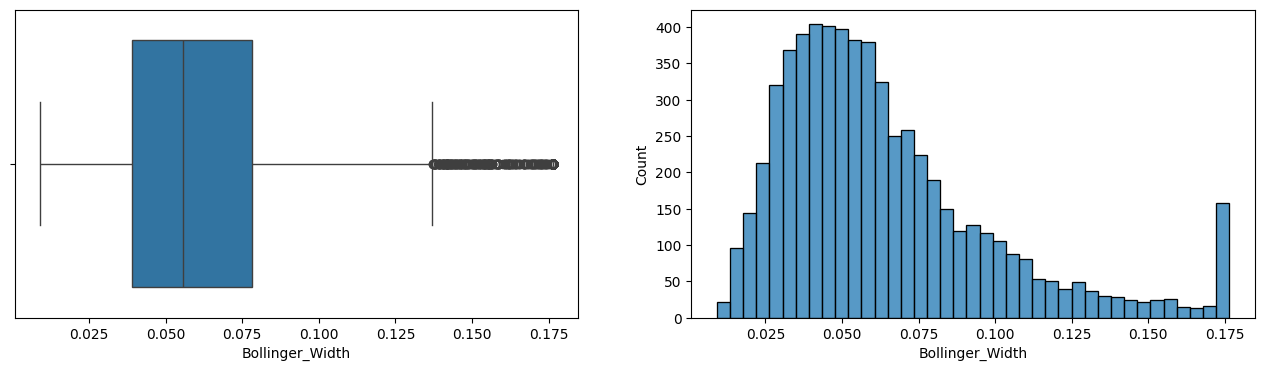

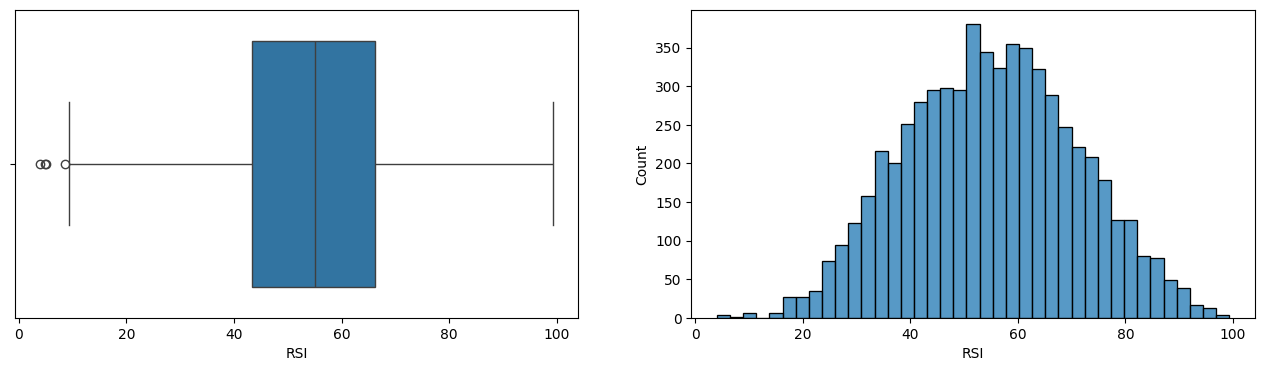

In [30]:
train_tec = back_lineal_foward(train_tec)
test_tec = back_lineal_foward(test_tec)

# Aplicar Winsorizer
winsor_2_5 = Winsorizer(
    capping_method='iqr',
    tail='right',
    fold=2.5,
    variables=['Bollinger_Width', 'RSI']
)

train_tec = winsor_2_5.fit_transform(train_tec)
test_tec = winsor_2_5.transform(test_tec)

for x in tec_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_tec[x], ax=ax1)
  sns.histplot(x=train_tec[x], ax=ax2)
  plt.show()


## **6. Variable Objetivo y Derivadas**

**Objetivo:** Etiqueta para aprendizaje supervisado.

* `Max_Drawdown_30d`
* `Max_Drawdown_30d_shift5`, `shift10`

Estas son las variables a predecir y sus versiones rezagadas, útiles para tareas autoregresivas o modelos secuenciales.

In [31]:
train_target = train_tec.copy()
test_target = test_tec.copy()

def max_drawdown_30d(df):
    df = df.copy()
    drawdowns = []

    close = df['Close'].values

    for i in range(len(df)):
      if i < 30:
          drawdowns.append(np.nan)
      else:
          past_window = close[i - 29:i]
          min_price = np.min(past_window)
          current_price = close[i-30]
          drawdown = (current_price - min_price) / current_price
          drawdowns.append(drawdown)

    df['Max_Drawdown_30d'] = drawdowns
    df['Max_Drawdown_30d_shift5'] = df['Max_Drawdown_30d'].shift(5)
    df['Max_Drawdown_30d_shift10'] = df['Max_Drawdown_30d'].shift(10)
    return df

train_target = max_drawdown_30d(train_target)
test_target = max_drawdown_30d(test_target)

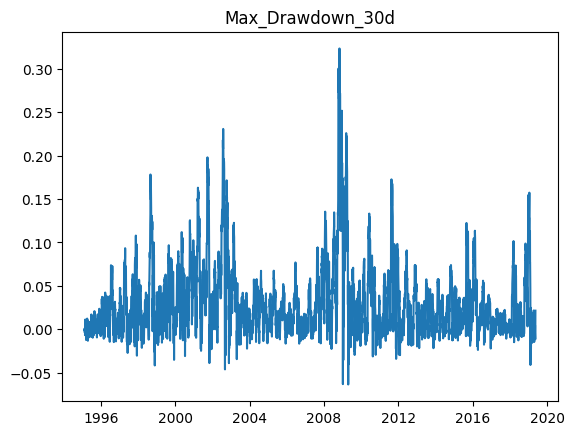

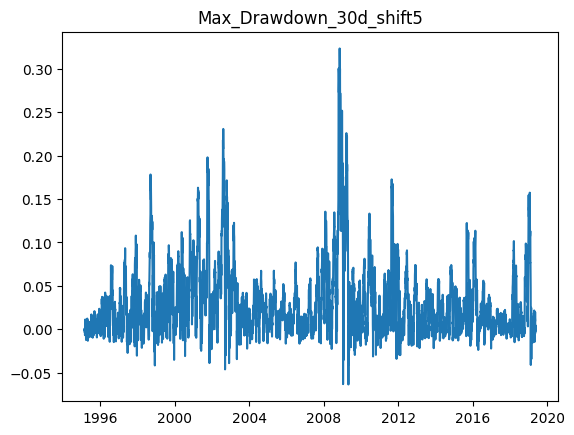

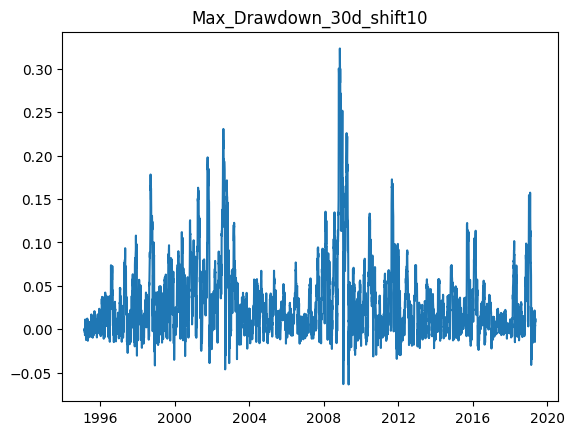

In [32]:
target_features = ['Max_Drawdown_30d', 'Max_Drawdown_30d_shift5', 'Max_Drawdown_30d_shift10']

for var in target_features:
  plt.plot(train_target[var])
  plt.title(var)
  plt.show()

### Outliers y Nulos

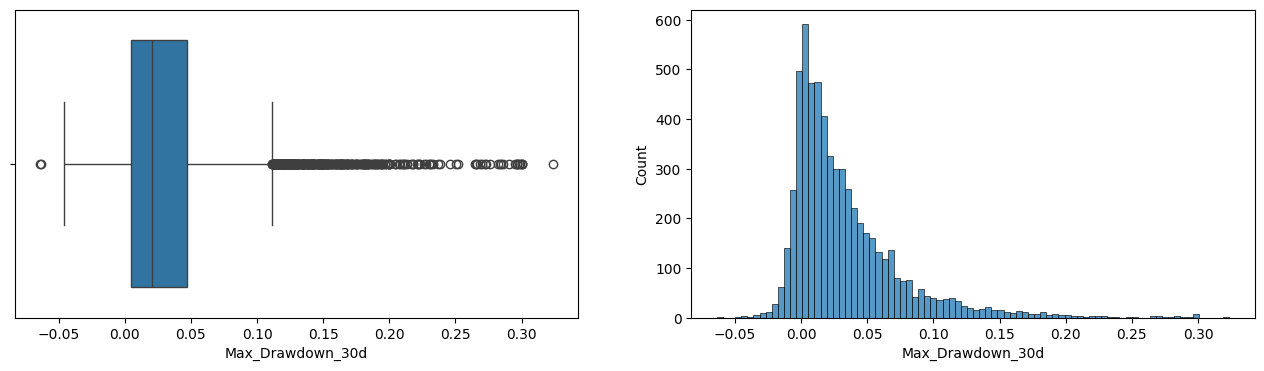

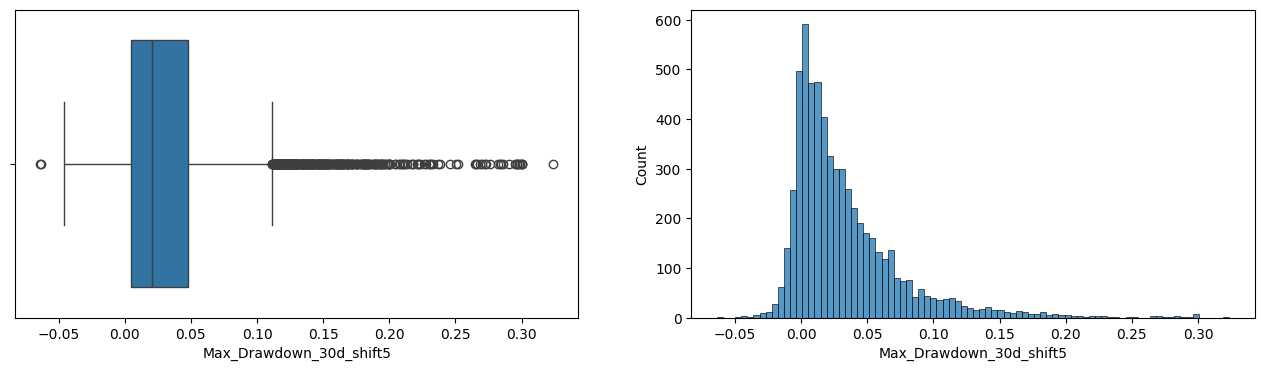

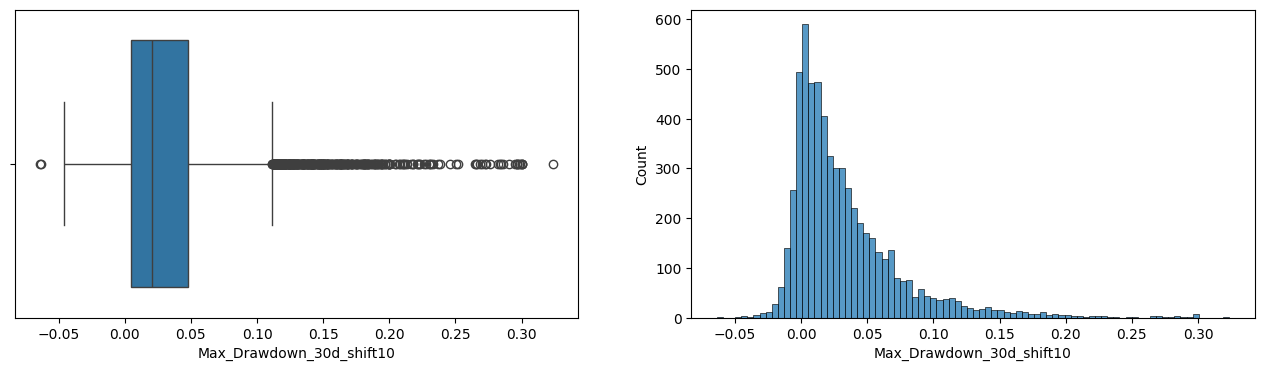

In [33]:
for x in target_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_target[x], ax=ax1)
  sns.histplot(x=train_target[x], ax=ax2)
  plt.show()


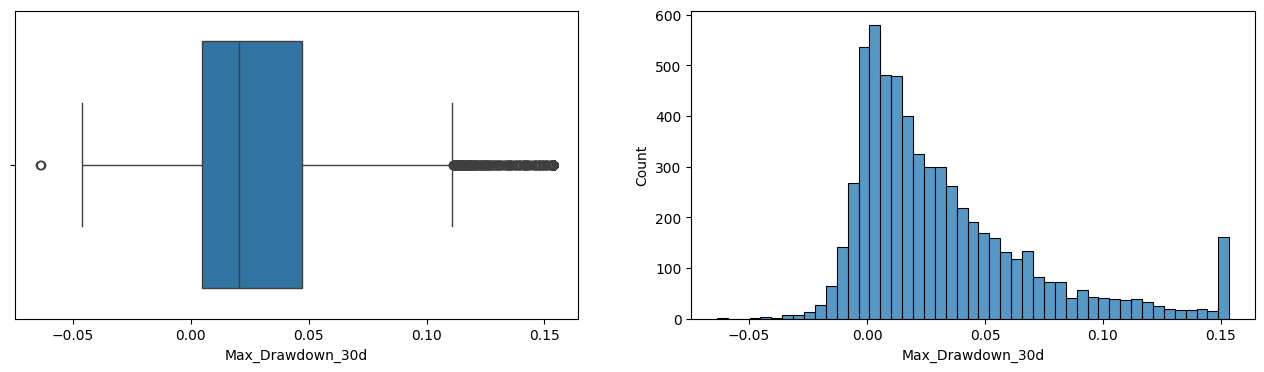

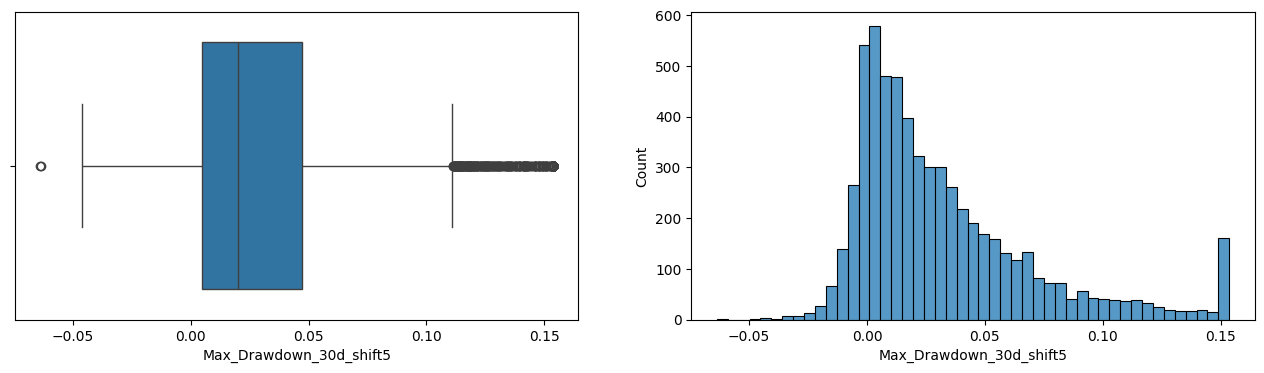

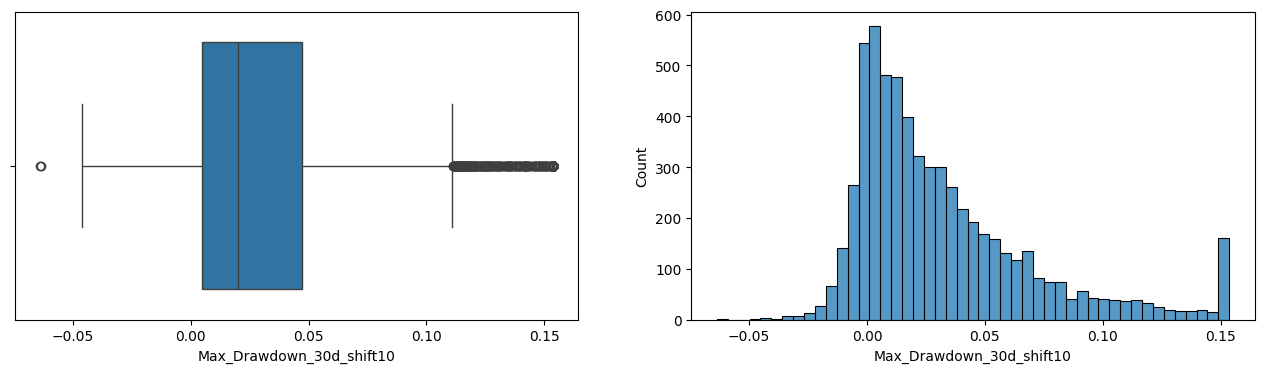

In [34]:
train_target = back_lineal_foward(train_target)
test_target = back_lineal_foward(test_target)

# Aplicar Winsorizer
winsor_2_5 = Winsorizer(
    capping_method='iqr',
    tail='right',
    fold=2.5,
    variables=['Max_Drawdown_30d','Max_Drawdown_30d_shift5', 'Max_Drawdown_30d_shift10']
)

train_target = winsor_2_5.fit_transform(train_target)
test_target = winsor_2_5.transform(test_target)

for x in target_features:
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))
  sns.boxplot(x=train_target[x], ax=ax1)
  sns.histplot(x=train_target[x], ax=ax2)
  plt.show()


# Eliminar targets que no uso

In [35]:
train_target = train_target.drop(columns=['Target5', 'Target10'])
test_target = test_target.drop(columns=['Target5', 'Target10'])

# PCA

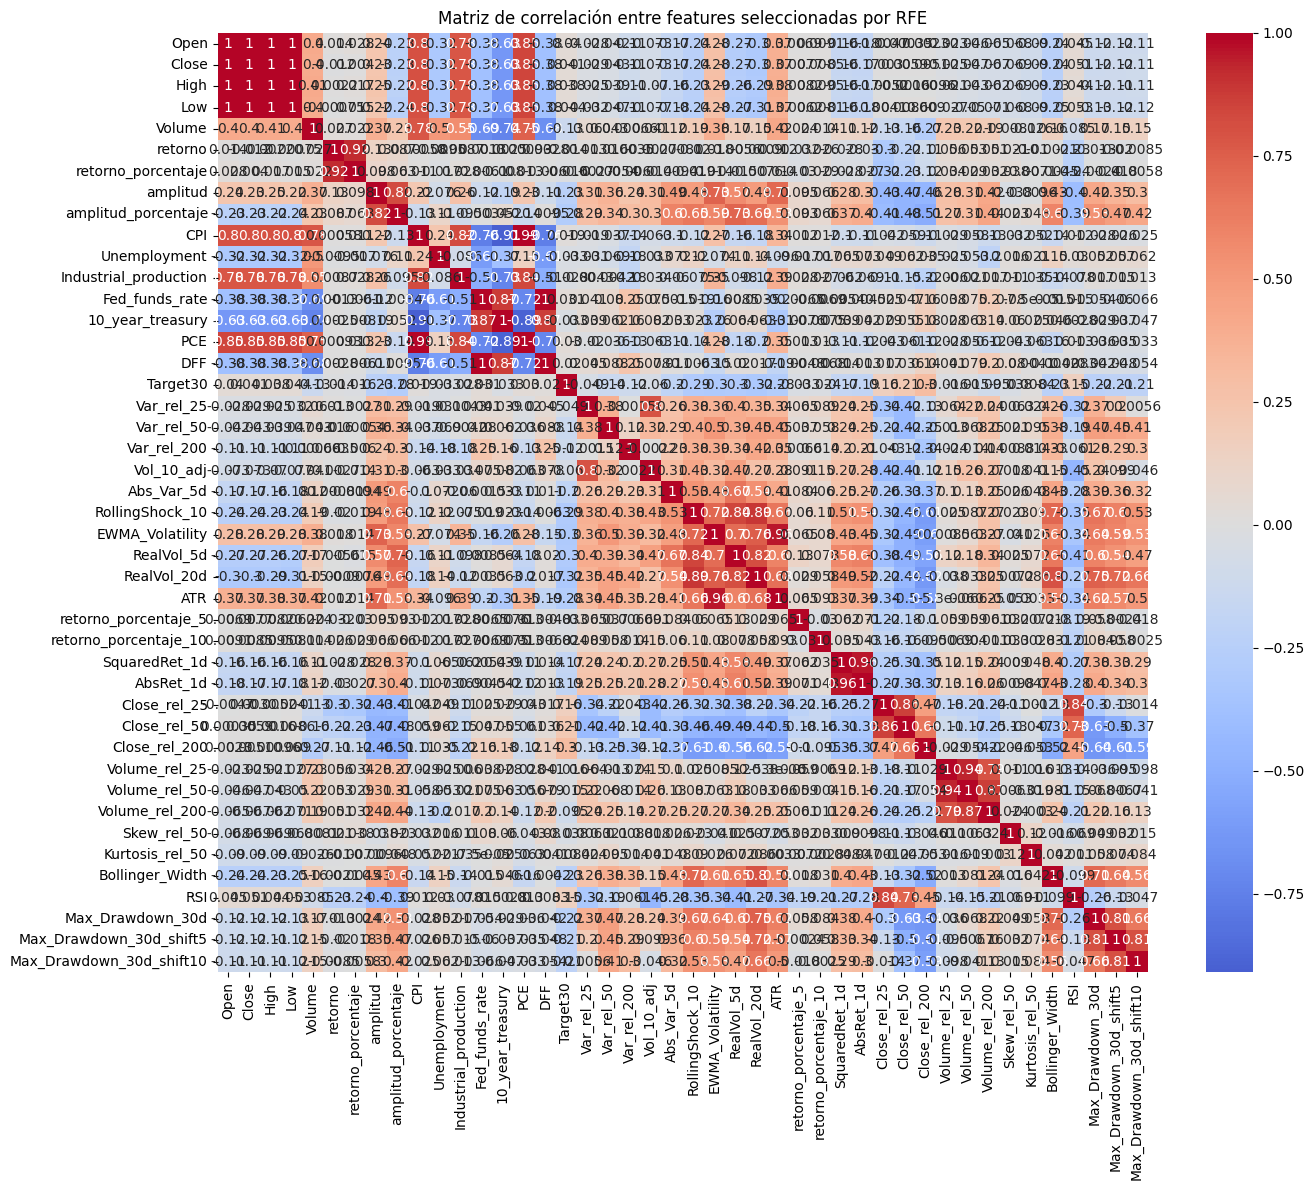

In [36]:
subset_corr = train_target[train_target.columns]

# Matriz de correlación
plt.figure(figsize=(14,12))
sns.heatmap(subset_corr.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre features seleccionadas por RFE")
plt.tight_layout()
plt.show()

,component_0,component_1,component_2,component_3,component_4,component_5,component_6,component_7,component_8,component_9,component_10,component_11,component_12,component_13,component_14,component_15,component_16,component_17,component_18,component_19,component_20,component_21,component_22,component_23,component_24,component_25,component_26,component_27,component_28,component_29,component_30,component_31,component_32,component_33,component_34,component_35,component_36,component_37,component_38,component_39,component_40,component_41,component_42
cumulative_variance,0.2517,0.4546,0.5361,0.6029,0.6598,0.7046,0.7366,0.7674,0.7954,0.8199,0.8436,0.8640,0.8827,0.8999,0.9146,0.9268,0.9370,0.9456,0.9533,0.9607,0.9658,0.9704,0.9742,0.9778,0.9810,0.9842,0.9870,0.9897,0.9915,0.9932,0.9947,0.9959,0.9968,0.9976,0.9984,0.9991,0.9995,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000


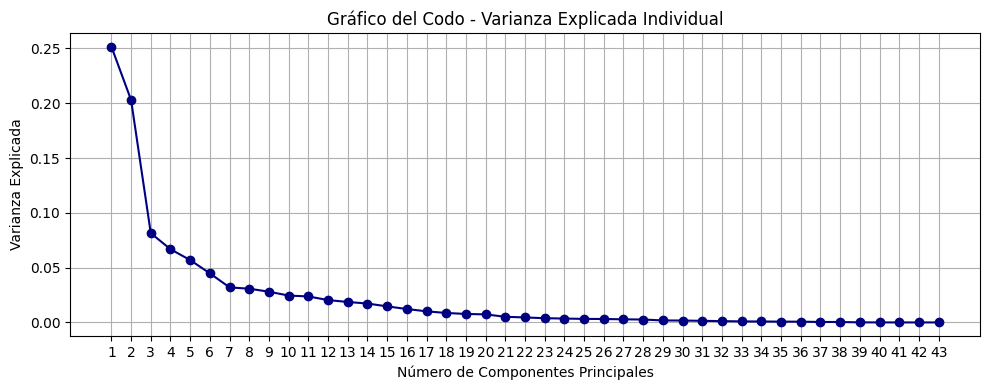

In [37]:
def evaluar_pca(train, vars):
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler
    train = train.copy()
    scaler= StandardScaler()
    train_scaled= scaler.fit_transform(train[vars])
    pca =PCA()
    train_pca =pca.fit_transform(train_scaled)
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)
    d={}
    for i,v in enumerate(cumulative_variance):
      d[f"component_{i}"]=v
    display(pd.DataFrame(d,index=["cumulative_variance"]))

    plt.figure(figsize=(10, 4))
    plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', linestyle='-', color='navy')
    plt.title("Gráfico del Codo - Varianza Explicada Individual")
    plt.xlabel("Número de Componentes Principales")
    plt.ylabel("Varianza Explicada")
    plt.xticks(range(1, len(explained_variance) + 1))
    plt.grid(True)
    plt.tight_layout()
    plt.show()


evaluar_pca(train_target, train_target.drop(columns=['Target30']).columns)

In [38]:
def aplicar_pca(train, test, vars, n_components,cols=[]):
  from sklearn.decomposition import PCA
  from sklearn.preprocessing import StandardScaler
  train = train.copy()
  test = test.copy()

  scaler = StandardScaler()
  train_scaled = scaler.fit_transform(train[vars])
  test_scaled = scaler.transform(test[vars])

  pca = PCA(n_components=n_components)
  pca.fit(train_scaled)
  train_pca = pca.transform(train_scaled)
  test_pca= pca.transform(test_scaled)

  train_pca = pd.DataFrame(train_pca,index=train.index,columns=cols)
  test_pca = pd.DataFrame(test_pca,index=test.index,columns=cols)


  train = pd.concat([train.drop(columns=vars),train_pca],axis=1)
  test = pd.concat([test.drop(columns=vars),test_pca],axis=1)

  return train,test


train_final, test_final = aplicar_pca(train_target, test_target, train_target.drop(columns='Target30').columns, 7,[f"pca_{i}" for i in range(1,7+1)])

# Evaluar

In [39]:
test_final = test_final[:-30]

In [40]:
def feature_importance_quantreg(df, target_column, quantile=0.5):
    X = df.drop(columns=target_column)
    y = df[target_column]

    X_const = sm.add_constant(X)

    model = QuantReg(y, X_const)
    results = model.fit(q=quantile)

    residuals = results.resid
    bp_test = het_breuschpagan(residuals, X_const)
    print(f"\n📈 Breusch-Pagan Test (sobre residuos de QuantReg):")
    print(f"  LM stat: {bp_test[0]}")
    print(f"  p-value: {bp_test[1]}")

    vif = pd.DataFrame()
    vif["variable"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    print(vif)

    print(results.summary())


feature_importance_quantreg(train_target, 'Target30')


📈 Breusch-Pagan Test (sobre residuos de QuantReg):
  LM stat: 1406.5808971978997
  p-value: 7.930116444631851e-267
                    variable                  VIF
0                       Open 692861481133922.5000
1                      Close 692861481133922.5000
2                       High 692861481133922.5000
3                        Low 692861481133922.5000
4                     Volume              36.7414
5                    retorno     63908040689.2365
6         retorno_porcentaje               7.1027
7                   amplitud    132585548756.0314
8        amplitud_porcentaje              37.3575
9                        CPI            5691.8477
10              Unemployment             171.8514
11     Industrial_production             918.2679
12            Fed_funds_rate             470.2602
13          10_year_treasury              78.7548
14                       PCE            2556.5142
15                       DFF             445.2502
16                Var_rel_25      

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1966: RuntimeWarning: invalid value encountered in sqrt
  return np.sqrt(eigvals[0]/eigvals[-1])


# Modelo

In [41]:
pip install arch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.3/978.3 kB 11.7 MB/s eta 0:00:00


In [42]:
from arch import arch_model
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import mean_absolute_error as mae
from scipy.stats import ks_2samp
import time

def evaluar_arch1_vs_realizada(train: pd.DataFrame,
                               test: pd.DataFrame,
                               targetcol: str,
                               p: int = 1,
                               window: int = 20):
    """
    Evalúa ARCH(1) vs volatilidad realizada.
    window: tamaño de la ventana para calcular volatilidad realizada.
    """

    # --- Validaciones ---
    if not isinstance(train, pd.DataFrame):
        raise TypeError("train must be a pandas DataFrame")
    if not isinstance(test, pd.DataFrame):
        raise TypeError("test must be a pandas DataFrame")
    if targetcol not in train.columns:
        raise ValueError(f"{targetcol} must be a column in the dataframe")

    # --- Datos escalados ---
    y_train = train[targetcol] * 100
    y_test = test[targetcol] * 100

    # --- Rolling forecast ARCH(1) ---
    preds, train_times, pred_times = [], [], []
    full_series = pd.concat([y_train, y_test])

    for i in range(len(y_train), len(full_series)):
        model = arch_model(full_series.iloc[:i],
                           vol="ARCH", p=p,
                           mean="Zero", rescale=False)

        # Tiempo de entrenamiento
        t_start = time.time()
        res = model.fit(disp="off")
        t_train_time = time.time() - t_start
        train_times.append(t_train_time)

        # Tiempo de predicción
        t_start_p = time.time()
        forecast = res.forecast(horizon=1, reindex=False)
        t_pred_time = time.time() - t_start_p
        pred_times.append(t_pred_time)

        sigma = np.sqrt(forecast.variance.values[-1, 0])
        preds.append(sigma)

    y_pred = pd.Series(preds, index=y_test.index)

    # --- Volatilidad realizada (sumatoria de cuadrados) ---
    realized_vol = y_test.rolling(window).apply(lambda x: np.sqrt(np.sum(x**2)), raw=True).dropna()
    y_pred_trim = y_pred[realized_vol.index]

    # --- Evaluación ---
    score = mae(realized_vol, y_pred_trim)
    p_value = ks_2samp(realized_vol, y_pred_trim).pvalue

    print(f"Error absoluto medio (ARCH(1) vs volatilidad realizada): {score:.4f}")
    print(f"Varianza volatilidad realizada: {np.var(realized_vol):.4f}")
    print(f"Varianza volatilidad predicha: {np.var(y_pred_trim):.4f}")
    print(f"p-value KS test: {p_value:.4e}")
    print(f"Tiempo promedio de entrenamiento: {np.mean(train_times):.6f} seg")
    print(f"Tiempo promedio de predicción: {np.mean(pred_times):.6f} seg")

    # parámetros y métricas
    parametros = {"p": p, "q": 0, "vol": "ARCH", "mean": "Zero"}
    metrics = {
        "mae": float(score),
        "var_realizada": float(np.var(realized_vol)),
        "var_predicha": float(np.var(y_pred_trim)),
        "ks_pvalue": float(p_value)
    }

    # --- Gráficos comparativos ---
    plt.figure(figsize=(15,5))
    plt.plot(realized_vol.index, realized_vol.values, label="Volatilidad realizada", color="tab:blue")
    plt.plot(y_pred_trim.index, y_pred_trim.values, label=f"Volatilidad predicha ARCH({p})", color="tab:orange")
    plt.title(f"ARCH({p}) vs Volatilidad realizada (window={window})")
    plt.legend()
    plt.show()

    return {
        "y_train": y_train,
        "y_test": y_test,
        "y_pred": y_pred,
        "realized_vol": realized_vol,
        "model_last": res,
        "train_times": train_times,
        "pred_times": pred_times,
        "parametros": parametros,
        "metrics": metrics
    }

# Evaluar

/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 4. The message is:
Inequality constraints incompatible
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/arch/univariate/base.py:768: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  warnings.warn(
/usr/local/lib/

Error absoluto medio (ARCH(1) vs volatilidad realizada): 19.9947
Varianza volatilidad realizada: 584.2298
Varianza volatilidad predicha: 22.5096
p-value KS test: 0.0000e+00
Tiempo promedio de entrenamiento: 1.672631 seg
Tiempo promedio de predicción: 0.002757 seg


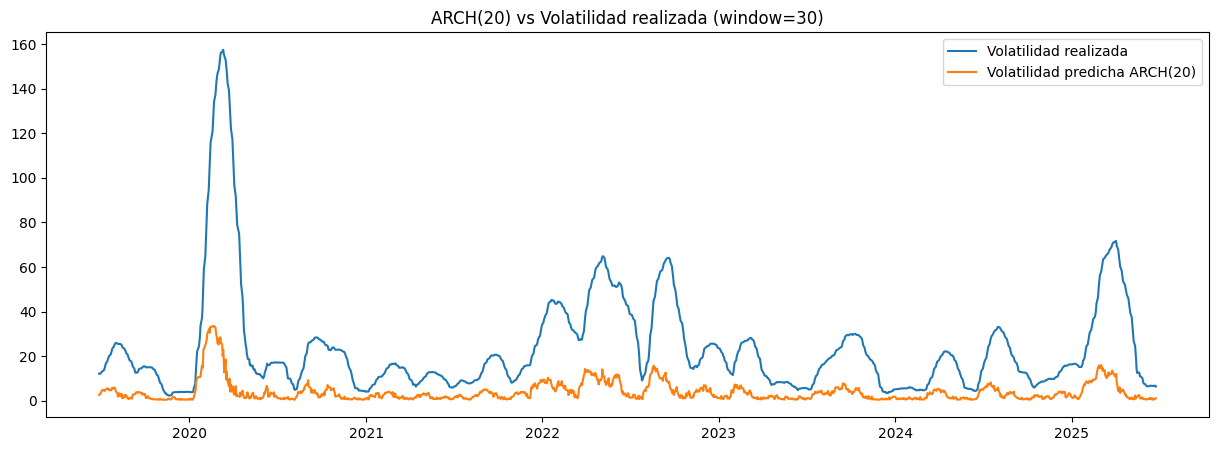

Parámetros: {'p': 20, 'q': 0, 'vol': 'ARCH', 'mean': 'Zero'}
Métricas: {'mae': 19.99470519405212, 'var_realizada': 584.229791234955, 'var_predicha': 22.509624824597445, 'ks_pvalue': 0.0}
Tiempo promedio entrenamiento: 1.6726310562434688
Tiempo promedio predicción: 0.002757447173107401


In [43]:
# --- Uso ARCH(1) ---
rets_arch1 = evaluar_arch1_vs_realizada(
    train=train_target,
    test=test_target,
    targetcol="Target30",
    p=20,
    window=30
)

# Acceso a resultados
print("Parámetros:", rets_arch1["parametros"])
print("Métricas:", rets_arch1["metrics"])
print("Tiempo promedio entrenamiento:", np.mean(rets_arch1["train_times"]))
print("Tiempo promedio predicción:", np.mean(rets_arch1["pred_times"]))


# Model Tracking

La funcion de abajo no se toca, solo se la va a llamar y pasar los parametros a ingestar en la tabla. Para esto se debe primero descargar los archivos .py de la libreria de facu junto con las credenciales e importarlos aca en el notebook

In [44]:
!pip install git+https://github.com/Facu4798/the_etl_library.git --upgrade
from la_libreria.authentication import Credentials
from la_libreria.connectors import MySQLConnector
from la_libreria.utils import get_ts


def model_tracking_insert(timestamp,
        target,
        nombre_modelo,
        n_train,
        n_test,
        features,
        parametros,
        metrics,
        last_date,
        first_date,
        ticker,
        training_time,
        prediction_time):

    import pandas as pd

    # credentials = Credentials().load(path="Credentials/db_prod.json")
    credentials = {
    "host":"estrie01-estimacionderiego1.j.aivencloud.com",
    "port":24195,
    "user":"avnadmin",
    "password":"AVNS_vBt5bLw5TLinvY6G_Eo",
    "database":"defaultdb"
    }
    conn = MySQLConnector(credentials)
    conn.test_connection()
    conn.connect()

    import json
    # fila por metrica
    rows = []
    for metric_name, metric_value in metrics.items():
        rows.append({
            "Timestamp": timestamp, # momento que se llama a la función
            "Target": target, # número de días
            "nombre_modelo": nombre_modelo,
            "n_train": n_train, # cantidad de datos de train
            "n_test": n_test, # cantidad de test
            "features": json.dumps(features), # X_test.columns
            "parametros": json.dumps(parametros), # parametros que usamos .get_params()
            "metric_name": metric_name,  # nombre de la métrica (MAE)
            "metric_value": metric_value, # valor de la métrica
            "last_date": last_date, # última fecha del dataset entero (train y test)
            "first_date": first_date, # primera fecha del dataset entero (train y test)
            "Ticker": ticker, # ^GSPC
            "training_time": training_time, # tiempo de entrenamiento
            "prediction_time": prediction_time # tiempo de predicción
        })

    model_tracking_table = pd.DataFrame(rows)
    res = conn.get_data("select * from model_tracking")

    # print(res)

    try:
        conn.create_table(
            data=model_tracking_table,
            table_name="model_tracking",
            pks=["Timestamp"],
            exceptions={"features":"TEXT", "parametros":"TEXT"}
        )
    except Exception:
        print("La tabla ya existe")
        pass

    conn.insert_data(
        data=model_tracking_table,
        table_name="model_tracking",
        pks=["Timestamp"]
    )

    display(conn.get_data("select * from model_tracking"))

    conn.close()

  Cloning https://github.com/Facu4798/the_etl_library.git to /tmp/pip-req-build-r6mtrsad
  Running command git clone --filter=blob:none --quiet https://github.com/Facu4798/the_etl_library.git /tmp/pip-req-build-r6mtrsad
  Resolved https://github.com/Facu4798/the_etl_library.git to commit d2d4b686f9563b2fab4c33008e919bb4af1c3374
  Preparing metadata (setup.py) ... done
  Created wheel for la_libreria: filename=la_libreria-0.1.5-py3-none-any.whl size=9655 sha256=be366dd245d2a1686ff33ea583d49aea2d6c1ee0fcfe5a9384d40775c62f9657
  Stored in directory: /tmp/pip-ephem-wheel-cache-nzf_jq8n/wheels/00/39/12/54032b1bb75babef21ad886ba5ddd107f78fd5ce53b936a6d9
Successfully built la_libreria


In [45]:
from la_libreria.utils import get_ts

# --- ARCH(1) ---
ticker = "^GSPC"

model_tracking_insert(
    timestamp=get_ts(),
    target="30",
    nombre_modelo="ARCH(1)",
    n_train=train_target.shape[0],
    n_test=test_target.shape[0],
    features=df.drop(columns=["Target5", "Target10", "Target30"]).columns.tolist(),
    parametros=rets_arch1["parametros"],
    metrics=rets_arch1["metrics"],
    last_date=df.index[-1],
    first_date=df.index[0],
    ticker=ticker,
    training_time=np.mean(rets_arch1["train_times"]),
    prediction_time=np.mean(rets_arch1["pred_times"])
)


Connection successful
Table model_tracking already exists.


,Timestamp,Target,nombre_modelo,n_train,n_test,features,parametros,metric_name,metric_value,last_date,first_date,Ticker,training_time,prediction_time
0,1757890039.2116432,5,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.1316,0.0041
1,1757890044.680194,10,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0750,0.0020
2,1757890049.9177208,30,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.1303,0.0025
3,1757891604.0608895,5,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0323,0.0018
4,1757891609.2749798,10,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0221,0.0016
5,1757891614.4431148,30,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0217,0.0021
6,1757891656.7480583,5,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0268,0.0017
7,1757891661.8786104,10,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0231,0.0018
8,1757891667.0504446,30,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0216,0.0016
9,1757891733.7552168,5,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0312,0.0020


Connection closed


Ejemplo de como insertar un experimento. El codigo no anda si lo corren porque deben poner sus variables

In [46]:

!pip install git+https://github.com/Facu4798/the_etl_library.git --upgrade
from la_libreria.authentication import Credentials
from la_libreria.connectors import MySQLConnector



credentials = Credentials().load(path="Credentials/db_prod.json")
credentials = {
    "host":"estrie01-estimacionderiego1.j.aivencloud.com",
    "port":24195,
    "user":"avnadmin",
    "password":"AVNS_vBt5bLw5TLinvY6G_Eo",
    "database":"defaultdb"
    }
conn = MySQLConnector(credentials)
conn.test_connection()
conn.connect()
display(conn.get_data("select * from model_tracking"))
conn.close()

  Cloning https://github.com/Facu4798/the_etl_library.git to /tmp/pip-req-build-_qaih38i
  Running command git clone --filter=blob:none --quiet https://github.com/Facu4798/the_etl_library.git /tmp/pip-req-build-_qaih38i
  Resolved https://github.com/Facu4798/the_etl_library.git to commit d2d4b686f9563b2fab4c33008e919bb4af1c3374
  Preparing metadata (setup.py) ... done
Credential file 'db_prod.json' not found
Connection successful


,Timestamp,Target,nombre_modelo,n_train,n_test,features,parametros,metric_name,metric_value,last_date,first_date,Ticker,training_time,prediction_time
0,1757890039.2116432,5,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.1316,0.0041
1,1757890044.680194,10,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0750,0.0020
2,1757890049.9177208,30,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.1303,0.0025
3,1757891604.0608895,5,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0323,0.0018
4,1757891609.2749798,10,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0221,0.0016
5,1757891614.4431148,30,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0217,0.0021
6,1757891656.7480583,5,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0268,0.0017
7,1757891661.8786104,10,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0231,0.0018
8,1757891667.0504446,30,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0216,0.0016
9,1757891733.7552168,5,LinearRegression,24485,1,"[""Open"", ""Close"", ""High"", ""Low"", ""Volume"", ""re...","{""copy_X"": true, ""fit_intercept"": true, ""n_job...",mae,None,2025-6-24,1927-12-30,^GSPC,0.0312,0.0020


Connection closed


In [47]:
from utils import get_ts

model_tracking_insert(
        timestamp=get_ts(),         # Pueden usar la libreria de facu para calcular el el horario de ahora
        target="5",                  # A cuantos dias es el target, creo q estan probando con 5
        nombre_modelo=model10.__class__.__name__,     # Ponen la variable de su modelo y deberia oobtener el nombre, por lo menos si es de scikit learn
        n_train=train.shape[0],                          # cant datos train
        n_test=test.shape[0],                           # cant datos test
        features=df.drop(columns=["Target5", "Target10", "Target30"]).columns.tolist(),      # Features utilizadas sin contar los targets
        parametros=model10.get_params(),                                          # Parametros guardados en un json
        metrics={
            "mae": None
        },                                                                       # Metricas guardadas en un json
        last_date=df.index[-1],                               # Ultima fecha considerada
        first_date=df.index[0],                               # primera fecha considerada
        ticker=ticker,                                        # Accion
        training_time= t_train10,                             # Tiempo de entrenamiento explicada celda de abajo
        prediction_time= t_pred10                             # Tiempo de prediccion explicada celda de abajo
    )

ModuleNotFoundError: No module named 'utils'

Ejemplo de como calcular algunas variables

In [ ]:
t_start5 = time.time()             # Inicio timer training
        model5.fit(
            df.drop(columns=get_drops(df, 5)).iloc[:-5],
            df["Target5"].iloc[:-5]
        )
t_train5 = time.time() - t_start5   # Fin timer training

t_start_p5 = time.time()          # Inicio timer pred
p5 = model5.predict(df.tail(1).drop(columns=get_drops(df,5)))[0]
t_pred5 = time.time() - t_start_p5    # Fin timer training
